**Dataset structure**
-----------------
Temporal range:
    January 1, 2020 (200101; yymmdd) – December 31, 2022 (221231; yymmdd)

Bands and spectral indices columns:

    Band / Index    Prefix    Column range
    --------------------------------------
    Blue            a_        [2 : 1096]
    Green           b_        [1097 : 2191]
    Red             c_        [2192 : 3286]
    NIR             d_        [3287 : 4381]
    BAI             e_        [4382 : 5476]
    EVI             f_        [5477 : 6571]
    GEMI            g_        [6572 : 7666]
    NDVI            h_        [7667 : 8761]
    NDWI            i_        [8762 : 9856]

Date of burn scars and labels columns

    Date / Labels    Column index
    --------------------------------------
    date_20          [9856]
    date_21          [9857]
    date_22          [9858]
    20_labels        [9859]
    21_labels        [9860]
    22_labels        [9861]

**Dataset download and conversion to parquet**

In [1]:
# ============================================
# UTILITY FUNCTIONS
# ============================================

import requests
from tqdm.auto import tqdm

def download(url: str, output: str) -> None:
    """
    Download a file from a URL with a progress bar.
    
    Parameters:
    -----------
    url : str
        URL of the file to download
    output : str
        Local path where the file will be saved
    """
    response = requests.get(url, stream=True)
    response.raise_for_status()
    
    total_size = int(response.headers.get("content-length", 0))
    
    with open(output, "wb") as f, tqdm(
        total=total_size,
        unit="B",
        unit_scale=True,
        desc=output.split("/")[-1],  # Show only filename in progress bar
    ) as pbar:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            f.write(chunk)
            pbar.update(len(chunk))

In [2]:
# ============================================
# DATA DOWNLOAD AND PREPROCESSING
# ============================================

import pandas as pd
import os

# ----------------------------------------------------------------------------
# FILE PATHS AND URLS
# ----------------------------------------------------------------------------

CSV_URL = "https://download.scidb.cn/download?fileId=e22fe8b8fa7b696516664d76a42ac2fe&path=/V4/Dataset_WFI.csv&fileName=Dataset_WFI.csv"
GPKG_URL = "https://download.scidb.cn/download?fileId=77d46df561845713803997015e2b6159&path=/V4/gpk_spatial_grid.gpkg&fileName=gpk_spatial_grid.gpkg"

BASE_DIR = "/home/jovyan/ScienceDB/Dataset"
csv_path = os.path.join(BASE_DIR, "Dataset_WFI.csv")
parquet_path = os.path.join(BASE_DIR, "Dataset_WFI.parquet")
gpkg_path = os.path.join(BASE_DIR, "gpk_spatial_grid.gpkg")

# Create directory if it doesn't exist
os.makedirs(BASE_DIR, exist_ok=True)

# ----------------------------------------------------------------------------
# DOWNLOAD AND CONVERT CSV TO PARQUET
# ----------------------------------------------------------------------------

if not os.path.exists(parquet_path):
    # Download CSV if needed
    if not os.path.exists(csv_path):
        download(CSV_URL, csv_path)
    else:
        print(f"✓ CSV already exists: {csv_path}")
    
    # Convert to Parquet (more efficient format)
    print("Converting CSV to Parquet...")
    df = pd.read_csv(csv_path)
    df.to_parquet(parquet_path, compression="snappy")
    
    # Free memory and clean up
    del df
    os.remove(csv_path)
    print(f"✓ Parquet saved: {parquet_path}")
    print(f"✓ CSV removed: {csv_path}")
else:
    print(f"✓ Parquet already exists: {parquet_path}")

# ----------------------------------------------------------------------------
# DOWNLOAD GEOPACKAGE
# ----------------------------------------------------------------------------

if not os.path.exists(gpkg_path):
    download(GPKG_URL, gpkg_path)
    print(f"✓ GeoPackage saved: {gpkg_path}")
else:
    print(f"✓ GeoPackage already exists: {gpkg_path}")

print("\n✓ All data files are ready!")

✓ Parquet already exists: /home/jovyan/ScienceDB/Dataset/Dataset_WFI.parquet
✓ GeoPackage already exists: /home/jovyan/ScienceDB/Dataset/gpk_spatial_grid.gpkg

✓ All data files are ready!


**Viewing column names**

In [3]:
# ============================================
# DATASET INSPECTION
# ============================================

import pandas as pd

# ----------------------------------------------------------------------------
# LOAD COLUMN NAMES (Metadata Only - Fast)
# ----------------------------------------------------------------------------

parquet_path = "/home/jovyan/ScienceDB/Dataset/Dataset_WFI.parquet"

# Read only the first 0 rows to get column names (no data loaded)
columns = pd.read_parquet(parquet_path).head(0).columns

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Total columns: {len(columns):,}")
print(f"Columns 1 to 25: {columns[1:25].tolist()}")

# Optional: Uncomment to see all columns
# print("\nAll columns:")
# print(columns.tolist())

DATASET OVERVIEW
Total columns: 9,862
Columns 1 to 25: ['a_200101', 'a_200102', 'a_200103', 'a_200104', 'a_200105', 'a_200106', 'a_200107', 'a_200108', 'a_200109', 'a_200110', 'a_200111', 'a_200112', 'a_200113', 'a_200114', 'a_200115', 'a_200116', 'a_200117', 'a_200118', 'a_200119', 'a_200120', 'a_200121', 'a_200122', 'a_200123', 'a_200124']


**Querying the yearly occurrence of burning**

In [4]:
# ============================================
# TEMPORAL ANALYSIS: TOP BURNED DAYS
# ============================================

import pandas as pd

# ----------------------------------------------------------------------------
# LOAD DATA
# ----------------------------------------------------------------------------

df = pd.read_parquet("/home/jovyan/ScienceDB/Dataset/Dataset_WFI.parquet")

# ----------------------------------------------------------------------------
# YEAR CONFIGURATIONS
# ----------------------------------------------------------------------------

year_configs = {
    '2020': {'date_col': 'date_20', 'label_col': '20_labels'},
    '2021': {'date_col': 'date_21', 'label_col': '21_labels'},
    '2022': {'date_col': 'date_22', 'label_col': '22_labels'},
}

# ----------------------------------------------------------------------------
# ANALYZE TOP 20 DAYS PER YEAR
# ----------------------------------------------------------------------------

for year, config in year_configs.items():
    date_col = config['date_col']
    label_col = config['label_col']
    
    print(f"\n{'='*80}")
    print(f"TOP 20 DAYS WITH MOST BURNED AREAS - {year}")
    print(f"{'='*80}")
    
    # Skip if columns are missing
    if date_col not in df.columns or label_col not in df.columns:
        print(f" Missing columns for {year}\n")
        continue
    
    # Filter rows with valid date
    df_year = df[df[date_col].notna()].copy()
    
    # Create binary indicators for each class
    df_year['is_tb'] = (df_year[label_col] == 'tb').astype(int)
    df_year['is_pb'] = (df_year[label_col] == 'pb').astype(int)
    df_year['is_nb'] = (df_year[label_col] == 'nb').astype(int)
    df_year['is_burning'] = (df_year[label_col] == 'tb').astype(int)
    
    total_cells_year = len(df_year)
    
    # Aggregate by date
    result = df_year.groupby(date_col).agg({
        'is_tb': 'sum',
        'is_pb': 'sum',
        'is_nb': 'sum',
        'is_burning': 'sum',
        'id': 'count'
    }).rename(columns={
        'id': 'total_cells_day',
        'is_burning': 'cells_with_burning'
    })
    
    # Derived metrics
    result['burned'] = result['is_tb'] + result['is_pb']
    result['pct_of_year'] = (result['cells_with_burning'] / total_cells_year) * 100
    result['tb_pct_day'] = (result['is_tb'] / result['total_cells_day']) * 100
    result['pb_pct_day'] = (result['is_pb'] / result['total_cells_day']) * 100
    result['nb_pct_day'] = (result['is_nb'] / result['total_cells_day']) * 100
    
    # Sort by burned area
    result = result.sort_values('burned', ascending=False)
    
    # Display top 20 days
    print(f"\n  {'Rank':<6} {'Date':<12} {'TB':<8} {'PB':<8} {'NB':<8} {'Burned':<12} {'% Year':<10}")
    print(f"  {'-'*70}")
    
    for i, (date, row) in enumerate(result.head(20).iterrows(), 1):
        print(f"  #{i:<5} {date:<12} {int(row['is_tb']):<8,} {int(row['is_pb']):<8,} "
              f"{int(row['is_nb']):<8,} {int(row['burned']):<12,} {row['pct_of_year']:.2f}%")
    
    # Year summary
    total_tb = int(result['is_tb'].sum())
    total_pb = int(result['is_pb'].sum())
    total_nb = int(result['is_nb'].sum())
    total_burned = total_tb + total_pb
    total_cells = int(result['total_cells_day'].sum())
    
    print(f"\n  {'='*70}")
    print(f"  SUMMARY - {year}")
    print(f"  {'='*70}")
    print(f"    Days analyzed        : {len(result)}")
    print(f"    Days with burning    : {len(result[result['cells_with_burning'] > 0])}")
    print(f"    Total cells          : {total_cells:,}")
    print(f"    TB (totally burned)  : {total_tb:,} ({total_tb/total_cells*100:.2f}%)")
    print(f"    PB (partially burned): {total_pb:,} ({total_pb/total_cells*100:.2f}%)")
    print(f"    NB (not burned)      : {total_nb:,} ({total_nb/total_cells*100:.2f}%)")
    print(f"    Total burned (TB+PB) : {total_burned:,} ({total_burned/total_cells*100:.2f}%)")


TOP 20 DAYS WITH MOST BURNED AREAS - 2020

  Rank   Date         TB       PB       NB       Burned       % Year    
  ----------------------------------------------------------------------
  #1     05-10-20     929      821      0        1,750        19.79%
  #2     15-10-20     388      423      0        811          8.26%
  #3     29-09-20     305      229      0        534          6.50%
  #4     30-09-20     91       114      0        205          1.94%
  #5     28-05-20     49       122      0        171          1.04%
  #6     23-05-20     12       144      0        156          0.26%
  #7     25-09-20     40       63       0        103          0.85%
  #8     04-07-20     48       53       0        101          1.02%
  #9     29-05-20     37       51       0        88           0.79%
  #10    19-09-20     17       52       0        69           0.36%
  #11    28-06-20     28       29       0        57           0.60%
  #12    09-09-20     20       36       0        56          

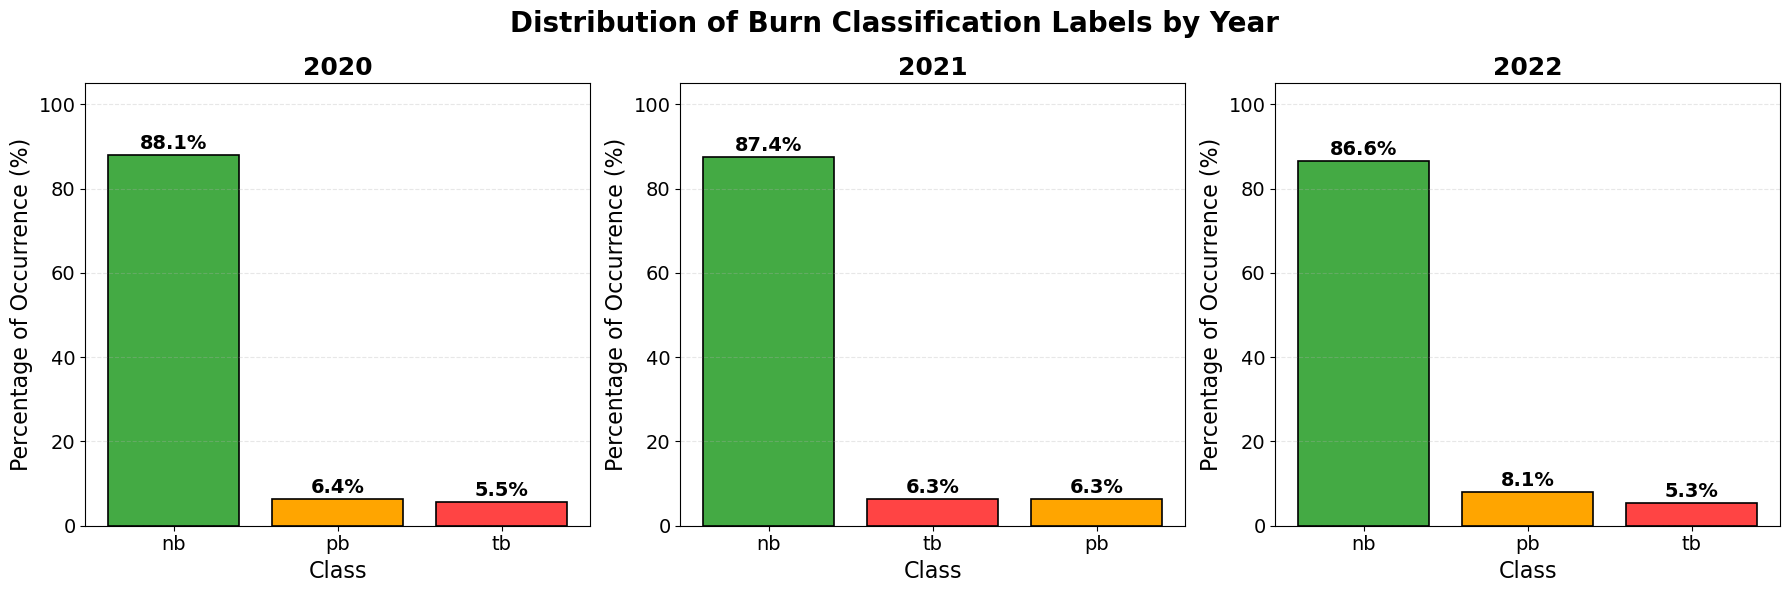


SUMMARY STATISTICS BY YEAR

                          2020 - LABEL DISTRIBUTION
                             Total observations: 38,957
  ----------------------------------------------------------------------------
            Class                 Count            Percentage              Visual          
  ----------------------------------------------------------------------------
     TB (totally burned)          2,151              5.52      %             █            
    PB (partially burned)         2,498              6.41      %             █            
       NB (not burned)            34,308            88.07      % ██████████████████████████
  ----------------------------------------------------------------------------


                          2021 - LABEL DISTRIBUTION
                             Total observations: 38,957
  ----------------------------------------------------------------------------
            Class                 Count            Percentage          

In [5]:
# ============================================
# LABEL DISTRIBUTION ANALYSIS
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------------------------------------------
# LOAD DATA
# ----------------------------------------------------------------------------

df = pd.read_parquet("/home/jovyan/ScienceDB/Dataset/Dataset_WFI.parquet")

# ----------------------------------------------------------------------------
# YEAR CONFIGURATIONS
# ----------------------------------------------------------------------------

year_configs = {
    '2020': {'label_col': '20_labels'},
    '2021': {'label_col': '21_labels'},
    '2022': {'label_col': '22_labels'},
}

# ----------------------------------------------------------------------------
# PLOT LABEL DISTRIBUTION BY YEAR
# ----------------------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Distribution of Burn Classification Labels by Year', fontsize=20, fontweight='bold')

# Color mapping for each class
class_colors = {'tb': '#FF4444', 'pb': '#FFA500', 'nb': '#44AA44'}
class_labels = {'tb': 'TB', 'pb': 'PB', 'nb': 'NB'}

for idx, (year, config) in enumerate(year_configs.items()):
    label_col = config['label_col']
    
    # Get labels and drop NaN values
    labels = df[label_col].dropna()
    counts = labels.value_counts()
    percentages = (counts / len(labels)) * 100
    
    # Create bar plot
    color_list = [class_colors[label] for label in percentages.index]
    bars = axes[idx].bar(percentages.index, percentages.values, 
                         color=color_list, edgecolor='black', linewidth=1.2)
    
    # Add percentage labels on top of bars
    for bar, pct in zip(bars, percentages.values):
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                       f'{pct:.1f}%', ha='center', va='bottom', 
                       fontsize=14, fontweight='bold')
    
    # Customize plot
    axes[idx].set_title(year, fontsize=18, fontweight='bold')
    axes[idx].set_xlabel('Class', fontsize=16)
    axes[idx].set_ylabel('Percentage of Occurrence (%)', fontsize=16)
    axes[idx].tick_params(axis='x', labelsize=14)
    axes[idx].tick_params(axis='y', labelsize=14)
    axes[idx].set_ylim(0, 105)
    axes[idx].grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# PRINT SUMMARY STATISTICS
# ----------------------------------------------------------------------------

print("\n" + "="*80)
print("SUMMARY STATISTICS BY YEAR")
print("="*80)

class_descriptions = {
    'tb': 'TB (totally burned)',
    'pb': 'PB (partially burned)',
    'nb': 'NB (not burned)'
}

for year, config in year_configs.items():
    label_col = config['label_col']
    labels = df[label_col].dropna()
    counts = labels.value_counts()
    percentages = (counts / len(labels)) * 100
    
    print(f"\n{'='*80}")
    print(f"{' ' * 25} {year} - LABEL DISTRIBUTION")
    print(f"{'='*80}")
    print(f"{' ' * 28} Total observations: {len(labels):,}")
    print(f"  {'-'*76}")
    print(f"  {'Class':^25} {'Count':^18} {'Percentage':^18} {'Visual':^25}")
    print(f"  {'-'*76}")
    
    for label in ['tb', 'pb', 'nb']:
        if label in counts:
            count = counts[label]
            pct = percentages[label]
            bar_length = int((pct / 100) * 30)
            visual_bar = '█' * bar_length
            print(f"  {class_descriptions[label]:^25} {count:^18,} {pct:^16.2f}% {visual_bar:^25}")
        else:
            print(f"  {class_descriptions[label]:^25} {0:^18,} {0:^16.2f}% {'':^25}")
    
    print(f"  {'-'*76}")
    print(f"{'='*80}\n")

**Preprocessing**

In [6]:
# ============================================
# FEATURE SELECTION FOR TRAINING
# ============================================

import pandas as pd

# ----------------------------------------------------------------------------
# LOAD COLUMN NAMES (Metadata Only)
# ----------------------------------------------------------------------------

parquet_path = "/home/jovyan/ScienceDB/Dataset/Dataset_WFI.parquet"
columns = pd.read_parquet(parquet_path).head(0).columns

# ----------------------------------------------------------------------------
# SEPARATE FEATURES BY YEAR
# ----------------------------------------------------------------------------

# Features: d_ (NDVI), g_ (GEMI), i_ (NDWI) for each year
features_2020 = [col for col in columns if col.startswith(("d_20", "g_20", "i_20"))]
features_2021 = [col for col in columns if col.startswith(("d_21", "g_21", "i_21"))]
features_2022 = [col for col in columns if col.startswith(("d_22", "g_22", "i_22"))]

# Label columns
label_2020 = '20_labels'
label_2021 = '21_labels'
label_2022 = '22_labels'

# ----------------------------------------------------------------------------
# TRAINING SUBSET (2020 + 2021)
# ----------------------------------------------------------------------------

# Combine features and labels for training (2020 and 2021)
training_subset = features_2020 + features_2021 + [label_2020, label_2021]

print("=" * 60)
print("FEATURE SUMMARY")
print("=" * 60)
print(f"Features 2020         : {len(features_2020):,}")
print(f"Features 2021         : {len(features_2021):,}")
print(f"Features 2022         : {len(features_2022):,}")
print(f"Training columns      : {len(training_subset):,}")
print(f"  - Features (2020+21): {len(features_2020) + len(features_2021):,}")
print(f"  - Labels            : 2 (20_labels, 21_labels)")
print(f"\nTraining subset: {len(features_2020)} (2020) + {len(features_2021)} (2021) + 2 labels")

# Optional: Preview first 5 training columns
# print(f"\nFirst 5 training columns:")
# print(training_subset[:5])

FEATURE SUMMARY
Features 2020         : 1,095
Features 2021         : 1,095
Features 2022         : 1,095
Training columns      : 2,192
  - Features (2020+21): 2,190
  - Labels            : 2 (20_labels, 21_labels)

Training subset: 1095 (2020) + 1095 (2021) + 2 labels


In [7]:
# ============================================
# DATA LOADING AND BALANCING
# ============================================

import pandas as pd

# ----------------------------------------------------------------------------
# LOAD TRAINING SUBSET (2020 + 2021)
# ----------------------------------------------------------------------------

parquet_path = "/home/jovyan/ScienceDB/Dataset/Dataset_WFI.parquet"

df = pd.read_parquet(
    parquet_path,
    columns=training_subset  # Defined in previous block
)

print("=" * 60)
print("DATA LOADED")
print("=" * 60)
print(f"Rows   : {len(df):,}")
print(f"Columns: {len(df.columns):,}")
print(f"Preview: {df.columns[:5].tolist()} ... {df.columns[-5:].tolist()}")

# ----------------------------------------------------------------------------
# COMBINE 2020 AND 2021 DATA
# ----------------------------------------------------------------------------

def prepare_year_data(df, feature_cols, label_col):
    """
    Extract and prepare data for a specific year.
    
    Parameters:
    -----------
    df : DataFrame
        Full dataset
    feature_cols : list
        Feature columns for the year
    label_col : str
        Label column name for the year
    
    Returns:
    --------
    DataFrame with features and unified 'label' column
    """
    features = [col for col in df.columns if col in feature_cols]
    df_year = df[features + [label_col]].copy()
    df_year = df_year.rename(columns={label_col: 'label'})
    df_year = df_year.dropna(subset=['label'])
    return df_year

# Prepare each year separately
df_2020 = prepare_year_data(df, features_2020, '20_labels')
df_2021 = prepare_year_data(df, features_2021, '21_labels')

print(f"\nYear 2020 samples: {len(df_2020):,}")
print(f"Year 2021 samples: {len(df_2021):,}")

# Combine years
df_combined = pd.concat([df_2020, df_2021], ignore_index=True)

print(f"\n{'='*60}")
print("COMBINED DATASET (Before Balancing)")
print("=" * 60)
print(f"Total samples: {len(df_combined):,}")
print(f"  TB (totally burned)  : {len(df_combined[df_combined['label'] == 'tb']):,}")
print(f"  PB (partially burned): {len(df_combined[df_combined['label'] == 'pb']):,}")
print(f"  NB (not burned)      : {len(df_combined[df_combined['label'] == 'nb']):,}")

# ----------------------------------------------------------------------------
# BALANCE DATASET (3 Classes)
# ----------------------------------------------------------------------------

# Separate by class
tb = df_combined[df_combined['label'] == 'tb']
pb = df_combined[df_combined['label'] == 'pb']
nb = df_combined[df_combined['label'] == 'nb']

# Balance to the smallest class
min_samples = min(len(tb), len(pb), len(nb))
print(f"\nBalancing to {min_samples:,} samples per class")

# Sample each class
tb_sampled = tb.sample(n=min_samples, random_state=42)
pb_sampled = pb.sample(n=min_samples, random_state=42)
nb_sampled = nb.sample(n=min_samples, random_state=42)

# Combine and shuffle
df_balanced = pd.concat([tb_sampled, pb_sampled, nb_sampled])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n{'='*60}")
print("BALANCED DATASET")
print("=" * 60)
print(f"Total samples: {len(df_balanced):,}")
print(f"  TB : {len(df_balanced[df_balanced['label'] == 'tb']):,}")
print(f"  PB : {len(df_balanced[df_balanced['label'] == 'pb']):,}")
print(f"  NB : {len(df_balanced[df_balanced['label'] == 'nb']):,}")

# Feature count by year
features_2020_loaded = [col for col in df_balanced.columns if col.startswith(('d_20', 'g_20', 'i_20'))]
features_2021_loaded = [col for col in df_balanced.columns if col.startswith(('d_21', 'g_21', 'i_21'))]

print(f"\nFeatures available:")
print(f"  2020: {len(features_2020_loaded):,}")
print(f"  2021: {len(features_2021_loaded):,}")

DATA LOADED
Rows   : 38,957
Columns: 2,192
Preview: ['d_200101', 'd_200102', 'd_200103', 'd_200104', 'd_200105'] ... ['i_211229', 'i_211230', 'i_211231', '20_labels', '21_labels']

Year 2020 samples: 38,957
Year 2021 samples: 38,957

COMBINED DATASET (Before Balancing)
Total samples: 77,914
  TB (totally burned)  : 4,618
  PB (partially burned): 4,935
  NB (not burned)      : 68,361

Balancing to 4,618 samples per class

BALANCED DATASET
Total samples: 13,854
  TB : 4,618
  PB : 4,618
  NB : 4,618

Features available:
  2020: 1,095
  2021: 1,095


**Training with Random Forest**

RANDOM FOREST TRAINING
Loaded 38,957 rows with 2,192 columns
2020 samples: 38,957
2021 samples: 38,957

Combined dataset: 77,914 samples
  TB: 4,618
  PB: 4,935
  NB: 68,361

Balancing to 4,618 samples per class

Balanced dataset: 13,854 samples
  TB: 4,618
  PB: 4,618
  NB: 4,618

Features: 1,095
X shape: (13854, 1095)
y shape: (13854,)

Training set: 11,083 samples
Test set    : 2,771 samples
  TB train: 3,694
  PB train: 3,694
  NB train: 3,695

Training Random Forest...

MODEL EVALUATION
Accuracy: 0.8066

Classification Report:
              precision    recall  f1-score   support

          NB       0.85      0.93      0.89       923
          PB       0.74      0.70      0.72       924
          TB       0.82      0.79      0.81       924

    accuracy                           0.81      2771
   macro avg       0.80      0.81      0.80      2771
weighted avg       0.80      0.81      0.80      2771



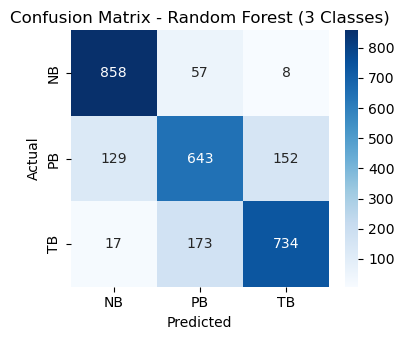


MODEL SAVED
Files saved to: /home/jovyan/ScienceDB/RF
  - random_forest_model.pkl
  - feature_names.pkl
  - model_metadata.pkl


In [8]:
# ============================================
# RANDOM FOREST TRAINING (3 CLASSES)
# ============================================

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import os

# ----------------------------------------------------------------------------
# UTILITY FUNCTIONS
# ----------------------------------------------------------------------------

def remove_year_prefix(col_name):
    """
    Remove year prefix from column names.
    
    Examples:
    ---------
    d_200101 -> d_0101
    g_210101 -> g_0101
    i_220101 -> i_0101
    """
    for prefix in ['d_20', 'd_21', 'g_20', 'g_21', 'i_20', 'i_21']:
        if col_name.startswith(prefix):
            return prefix[:2] + '_' + col_name[4:]
    return col_name

# ----------------------------------------------------------------------------
# 1. LOAD AND PREPARE DATA
# ----------------------------------------------------------------------------

print("=" * 60)
print("RANDOM FOREST TRAINING")
print("=" * 60)

parquet_path = "/home/jovyan/ScienceDB/Dataset/Dataset_WFI.parquet"

# Load column names
columns = pd.read_parquet(parquet_path).head(0).columns

# Get features for both years
features_2020 = [col for col in columns if col.startswith(('d_20', 'g_20', 'i_20'))]
features_2021 = [col for col in columns if col.startswith(('d_21', 'g_21', 'i_21'))]

# Load data (only needed columns)
df = pd.read_parquet(
    parquet_path,
    columns=features_2020 + features_2021 + ['20_labels', '21_labels']
)
print(f"Loaded {len(df):,} rows with {len(df.columns):,} columns")

# ----------------------------------------------------------------------------
# 2. PREPARE COMBINED DATASET
# ----------------------------------------------------------------------------

def prepare_year_data(df, feature_cols, label_col):
    """Extract and rename features for a specific year."""
    df_year = df[feature_cols + [label_col]].copy()
    
    # Remove year prefix from feature names
    rename_mapping = {col: remove_year_prefix(col) for col in feature_cols}
    df_year = df_year.rename(columns=rename_mapping)
    df_year = df_year.rename(columns={label_col: 'label'})
    
    return df_year

# Prepare each year
df_2020 = prepare_year_data(df, features_2020, '20_labels')
df_2021 = prepare_year_data(df, features_2021, '21_labels')

print(f"2020 samples: {len(df_2020):,}")
print(f"2021 samples: {len(df_2021):,}")

# Combine years
df_combined = pd.concat([df_2020, df_2021], ignore_index=True)

print(f"\nCombined dataset: {len(df_combined):,} samples")
print(f"  TB: {len(df_combined[df_combined['label'] == 'tb']):,}")
print(f"  PB: {len(df_combined[df_combined['label'] == 'pb']):,}")
print(f"  NB: {len(df_combined[df_combined['label'] == 'nb']):,}")

# ----------------------------------------------------------------------------
# 3. BALANCE DATASET (3 Classes)
# ----------------------------------------------------------------------------

tb = df_combined[df_combined['label'] == 'tb']
pb = df_combined[df_combined['label'] == 'pb']
nb = df_combined[df_combined['label'] == 'nb']

min_samples = min(len(tb), len(pb), len(nb))
print(f"\nBalancing to {min_samples:,} samples per class")

tb_sampled = tb.sample(n=min_samples, random_state=42)
pb_sampled = pb.sample(n=min_samples, random_state=42)
nb_sampled = nb.sample(n=min_samples, random_state=42)

df_balanced = pd.concat([tb_sampled, pb_sampled, nb_sampled])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nBalanced dataset: {len(df_balanced):,} samples")
print(f"  TB: {len(df_balanced[df_balanced['label'] == 'tb']):,}")
print(f"  PB: {len(df_balanced[df_balanced['label'] == 'pb']):,}")
print(f"  NB: {len(df_balanced[df_balanced['label'] == 'nb']):,}")

# ----------------------------------------------------------------------------
# 4. PREPARE FEATURES
# ----------------------------------------------------------------------------

feature_cols = [col for col in df_balanced.columns if col.startswith(('d_', 'g_', 'i_'))]
print(f"\nFeatures: {len(feature_cols):,}")

X = df_balanced[feature_cols].fillna(0)
y = df_balanced['label']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# ----------------------------------------------------------------------------
# 5. TRAIN-TEST SPLIT
# ----------------------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set: {len(X_train):,} samples")
print(f"Test set    : {len(X_test):,} samples")
print(f"  TB train: {len(y_train[y_train == 'tb']):,}")
print(f"  PB train: {len(y_train[y_train == 'pb']):,}")
print(f"  NB train: {len(y_train[y_train == 'nb']):,}")

# ----------------------------------------------------------------------------
# 6. TRAIN RANDOM FOREST
# ----------------------------------------------------------------------------

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

print("\nTraining Random Forest...")
rf_model.fit(X_train, y_train)

# ----------------------------------------------------------------------------
# 7. EVALUATE
# ----------------------------------------------------------------------------

y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("\n" + "=" * 60)
print("MODEL EVALUATION")
print("=" * 60)
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['NB', 'PB', 'TB']))

# Confusion Matrix
plt.figure(figsize=(4, 3.5))
cm = confusion_matrix(y_test, y_pred, labels=['nb', 'pb', 'tb'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NB', 'PB', 'TB'], 
            yticklabels=['NB', 'PB', 'TB'])
plt.title('Confusion Matrix - Random Forest (3 Classes)', fontsize=12)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# 8. SAVE MODEL
# ----------------------------------------------------------------------------

save_dir = '/home/jovyan/ScienceDB/RF'
os.makedirs(save_dir, exist_ok=True)

# Save model
joblib.dump(rf_model, os.path.join(save_dir, 'random_forest_model.pkl'))

# Save feature names
joblib.dump(feature_cols, os.path.join(save_dir, 'feature_names.pkl'))

# Save metadata
metadata = {
    'model_type': 'RandomForestClassifier',
    'train_years': [2020, 2021],
    'test_year': 2022,
    'features_used': ['d_', 'g_', 'i_'],
    'n_estimators': 100,
    'max_depth': 10,
    'min_samples_split': 5,
    'min_samples_leaf': 2,
    'random_state': 42,
    'n_features': len(feature_cols),
    'train_samples': len(X_train),
    'test_samples': len(X_test),
    'accuracy': accuracy,
    'classes': ['nb', 'pb', 'tb']
}
joblib.dump(metadata, os.path.join(save_dir, 'model_metadata.pkl'))

print("\n" + "=" * 60)
print("MODEL SAVED")
print("=" * 60)
print(f"Files saved to: {save_dir}")
print(f"  - random_forest_model.pkl")
print(f"  - feature_names.pkl")
print(f"  - model_metadata.pkl")

**Generalization with RF**

RANDOM FOREST - 2022 GENERALIZATION

Model loaded:
  Trained on: [2020, 2021]
  Accuracy  : 0.8066
  Classes   : ['nb', 'pb', 'tb']

PREPARING TEST DATA (2022)
Samples: 38,957
  TB: 2,082 (5.3%)
  PB: 3,146 (8.1%)
  NB: 33,729 (86.6%)

PREDICTING ON 2022 DATA

Predictions distribution:
  Predicted TB: 2,441 (6.3%)
  Predicted PB: 16,767 (43.0%)
  Predicted NB: 19,749 (50.7%)

EVALUATION 1: 3 CLASSES (TB, PB, NB)


/opt/conda/envs/geospatial/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(



Accuracy: 0.5651
Performance drop: 0.2415 (24.15%)

Classification Report:
              precision    recall  f1-score   support

          NB       0.96      0.56      0.71     33729
          PB       0.13      0.67      0.21      3146
          TB       0.38      0.44      0.41      2082

    accuracy                           0.57     38957
   macro avg       0.49      0.56      0.44     38957
weighted avg       0.86      0.57      0.65     38957



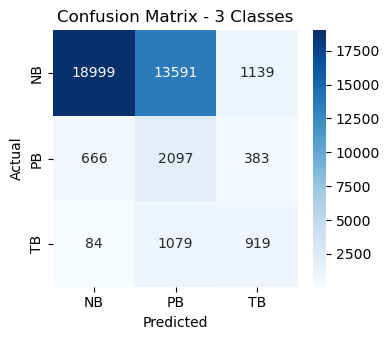


EVALUATION 2: BINARY (TB vs PB+NB) - POST-CLASSIFICATION

Accuracy : 0.9311
Precision: 0.3765
Recall   : 0.4414
F1-Score : 0.4064

Confusion Matrix (TB vs PB+NB):
              Predicted
              TB    PB+NB
  Actual TB     919    1163
         PB+NB  1522   35353


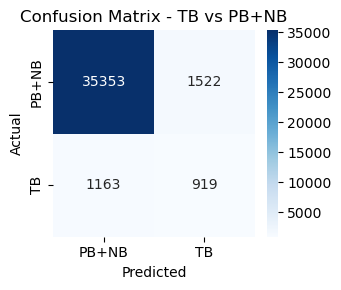


SUMMARY

Evaluation 1 (3 classes: TB, PB, NB):
  Accuracy: 0.5651
  Performance drop: 0.2415 (24.15%)

Evaluation 2 (Binary: TB vs PB+NB) - POST-CLASSIFICATION:
  Accuracy : 0.9311
  Precision: 0.3765
  Recall   : 0.4414
  F1-Score : 0.4064

Test distribution:
  TB     : 2,082
  PB     : 3,146
  NB     : 33,729
  PB+NB  : 36,875

GENERALIZATION COMPLETE


In [9]:
# ============================================
# RANDOM FOREST GENERALIZATION (2022)
# ============================================

import pandas as pd
import joblib
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import os

# ----------------------------------------------------------------------------
# UTILITY FUNCTIONS
# ----------------------------------------------------------------------------

def remove_year_prefix_2022(col_name):
    """Remove '22' prefix from 2022 column names."""
    if col_name.startswith(('d_22', 'g_22', 'i_22')):
        return col_name[:2] + '_' + col_name[4:]
    return col_name

# ----------------------------------------------------------------------------
# 1. LOAD MODEL
# ----------------------------------------------------------------------------

print("=" * 60)
print("RANDOM FOREST - 2022 GENERALIZATION")
print("=" * 60)

model_dir = '/home/jovyan/ScienceDB/RF'
rf_model = joblib.load(os.path.join(model_dir, 'random_forest_model.pkl'))
metadata = joblib.load(os.path.join(model_dir, 'model_metadata.pkl'))
feature_names = joblib.load(os.path.join(model_dir, 'feature_names.pkl'))

print("\nModel loaded:")
print(f"  Trained on: {metadata['train_years']}")
print(f"  Accuracy  : {metadata['accuracy']:.4f}")
print(f"  Classes   : {metadata['classes']}")

# ----------------------------------------------------------------------------
# 2. LOAD AND PREPARE TEST DATA (2022)
# ----------------------------------------------------------------------------

print("\n" + "=" * 60)
print("PREPARING TEST DATA (2022)")
print("=" * 60)

parquet_path = "/home/jovyan/ScienceDB/Dataset/Dataset_WFI.parquet"

# Load 2022 data (labels + features)
df = pd.read_parquet(
    parquet_path,
    columns=['22_labels'] + [col for col in pd.read_parquet(parquet_path).columns 
                             if col.startswith(('d_22', 'g_22', 'i_22'))]
)

# Filter for all three classes
df_2022 = df[df['22_labels'].isin(['tb', 'pb', 'nb'])].copy()

# Rename 2022 features (remove '22' prefix)
feature_cols_2022 = [col for col in df_2022.columns if col.startswith(('d_22', 'g_22', 'i_22'))]
rename_mapping = {col: remove_year_prefix_2022(col) for col in feature_cols_2022}
df_2022_renamed = df_2022.rename(columns=rename_mapping)

# Align features with training order
X_test = np.zeros((len(df_2022_renamed), len(feature_names)), dtype=np.float32)
for i, col in enumerate(feature_names):
    if col in df_2022_renamed.columns:
        X_test[:, i] = df_2022_renamed[col].values.astype(np.float32)
    # Missing features are filled with 0

y_test = df_2022_renamed['22_labels'].values

print(f"Samples: {len(X_test):,}")
print(f"  TB: {sum(y_test == 'tb'):,} ({sum(y_test == 'tb')/len(y_test)*100:.1f}%)")
print(f"  PB: {sum(y_test == 'pb'):,} ({sum(y_test == 'pb')/len(y_test)*100:.1f}%)")
print(f"  NB: {sum(y_test == 'nb'):,} ({sum(y_test == 'nb')/len(y_test)*100:.1f}%)")

# ----------------------------------------------------------------------------
# 3. PREDICT ON 2022
# ----------------------------------------------------------------------------

print("\n" + "=" * 60)
print("PREDICTING ON 2022 DATA")
print("=" * 60)

y_pred = rf_model.predict(X_test)

print("\nPredictions distribution:")
print(f"  Predicted TB: {sum(y_pred == 'tb'):,} ({sum(y_pred == 'tb')/len(y_pred)*100:.1f}%)")
print(f"  Predicted PB: {sum(y_pred == 'pb'):,} ({sum(y_pred == 'pb')/len(y_pred)*100:.1f}%)")
print(f"  Predicted NB: {sum(y_pred == 'nb'):,} ({sum(y_pred == 'nb')/len(y_pred)*100:.1f}%)")

# ----------------------------------------------------------------------------
# 4. EVALUATION: 3 CLASSES (TB, PB, NB)
# ----------------------------------------------------------------------------

print("\n" + "=" * 60)
print("EVALUATION 1: 3 CLASSES (TB, PB, NB)")
print("=" * 60)

accuracy_3classes = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy_3classes:.4f}")
print(f"Performance drop: {metadata['accuracy'] - accuracy_3classes:.4f} "
      f"({(metadata['accuracy'] - accuracy_3classes) * 100:.2f}%)")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['NB', 'PB', 'TB']))

# Confusion Matrix - 3 classes
plt.figure(figsize=(4, 3.5))
cm_3 = confusion_matrix(y_test, y_pred, labels=['nb', 'pb', 'tb'])
sns.heatmap(cm_3, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NB', 'PB', 'TB'], 
            yticklabels=['NB', 'PB', 'TB'])
plt.title('Confusion Matrix - 3 Classes', fontsize=12)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# 5. BINARY EVALUATION (TB vs PB+NB) - POST-CLASSIFICATION
# ----------------------------------------------------------------------------

print("\n" + "=" * 60)
print("EVALUATION 2: BINARY (TB vs PB+NB) - POST-CLASSIFICATION")
print("=" * 60)

# Convert to binary: TB = 1, PB+NB = 0
y_test_binary = np.array([1 if label == 'tb' else 0 for label in y_test])
y_pred_binary = np.array([1 if pred == 'tb' else 0 for pred in y_pred])

# Confusion matrix values
tp = np.sum((y_test_binary == 1) & (y_pred_binary == 1))
tn = np.sum((y_test_binary == 0) & (y_pred_binary == 0))
fp = np.sum((y_test_binary == 0) & (y_pred_binary == 1))
fn = np.sum((y_test_binary == 1) & (y_pred_binary == 0))

accuracy_binary = accuracy_score(y_test_binary, y_pred_binary)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nAccuracy : {accuracy_binary:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

print(f"\nConfusion Matrix (TB vs PB+NB):")
print(f"              Predicted")
print(f"              TB    PB+NB")
print(f"  Actual TB   {tp:>5}   {fn:>5}")
print(f"         PB+NB {fp:>5}   {tn:>5}")

# Confusion Matrix - 2 classes
plt.figure(figsize=(3.5, 3))
cm_2 = confusion_matrix(y_test_binary, y_pred_binary)
sns.heatmap(cm_2, annot=True, fmt='d', cmap='Blues',
            xticklabels=['PB+NB', 'TB'], 
            yticklabels=['PB+NB', 'TB'])
plt.title('Confusion Matrix - TB vs PB+NB', fontsize=12)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# 6. SUMMARY
# ----------------------------------------------------------------------------

print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"\nEvaluation 1 (3 classes: TB, PB, NB):")
print(f"  Accuracy: {accuracy_3classes:.4f}")
print(f"  Performance drop: {metadata['accuracy'] - accuracy_3classes:.4f} "
      f"({(metadata['accuracy'] - accuracy_3classes) * 100:.2f}%)")

print(f"\nEvaluation 2 (Binary: TB vs PB+NB) - POST-CLASSIFICATION:")
print(f"  Accuracy : {accuracy_binary:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall   : {recall:.4f}")
print(f"  F1-Score : {f1:.4f}")

print(f"\nTest distribution:")
print(f"  TB     : {sum(y_test == 'tb'):,}")
print(f"  PB     : {sum(y_test == 'pb'):,}")
print(f"  NB     : {sum(y_test == 'nb'):,}")
print(f"  PB+NB  : {sum(y_test != 'tb'):,}")

print("\n" + "=" * 60)
print("GENERALIZATION COMPLETE")
print("=" * 60)

**Training with LSTM linear**

Using device: cuda
GPU: Tesla V100-SXM2-16GB
LSTM LINEAR TRAINING
Loaded 38,957 rows with 2,192 columns
2020 samples: 38,957
2021 samples: 38,957

Combined dataset: 77,914 samples
  TB: 4,618
  PB: 4,935
  NB: 68,361

Balancing to 4,618 samples per class

Balanced dataset: 13,854 samples
  TB: 4,618
  PB: 4,618
  NB: 4,618

Features: 1,095
X shape: (13854, 1095)
Class distribution:
  NB: 4,618
  PB: 4,618
  TB: 4,618
Total features (timesteps): 1,095
X_reshaped shape: (13854, 1095, 1)

Training set: 11,083 samples
Test set    : 2,771 samples
Timesteps   : 1,095
LSTMModel(
  (lstm): LSTM(1, 24, num_layers=2, batch_first=True)
  (bn1): BatchNorm1d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=24, out_features=3, bias=True)
)

Total parameters: 7,515

Training LSTM (3 classes: TB, PB, NB)...
Epoch  10/200 - Train Loss: 0.9559, Val Loss: 0.9231, Val Acc: 0.5496
Epoch  20/200 - Train Loss: 0.7074, Va

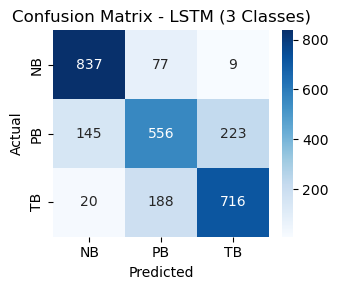

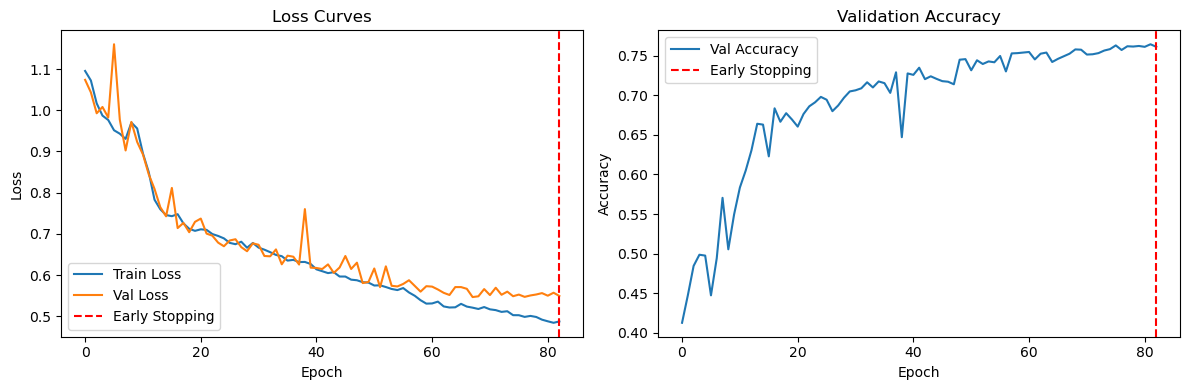


LSTM TRAINING COMPLETE
Device           : cuda
Timesteps        : 1,095
Epochs trained   : 83
Total parameters : 7,515
Accuracy (3 cls) : 0.7611
Best val loss    : 0.5467
Models saved to  : /home/jovyan/ScienceDB/LSTM/Linear


In [10]:
# ============================================
# LSTM LINEAR TRAINING (3 CLASSES)
# ============================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import os

# ----------------------------------------------------------------------------
# GPU CONFIGURATION
# ----------------------------------------------------------------------------

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("GPU not available, using CPU")

# Set seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# ----------------------------------------------------------------------------
# UTILITY FUNCTIONS
# ----------------------------------------------------------------------------

def remove_year_prefix(col_name):
    """Remove year prefix from column names."""
    for prefix in ['d_20', 'd_21', 'g_20', 'g_21', 'i_20', 'i_21']:
        if col_name.startswith(prefix):
            return prefix[:2] + '_' + col_name[4:]
    return col_name

# ----------------------------------------------------------------------------
# 1. LOAD AND PREPARE DATA
# ----------------------------------------------------------------------------

print("=" * 60)
print("LSTM LINEAR TRAINING")
print("=" * 60)

parquet_path = "/home/jovyan/ScienceDB/Dataset/Dataset_WFI.parquet"

# Load column names
columns = pd.read_parquet(parquet_path).head(0).columns

# Get features for both years
features_2020 = [col for col in columns if col.startswith(('d_20', 'g_20', 'i_20'))]
features_2021 = [col for col in columns if col.startswith(('d_21', 'g_21', 'i_21'))]

# Load data
df = pd.read_parquet(
    parquet_path,
    columns=features_2020 + features_2021 + ['20_labels', '21_labels']
)
print(f"Loaded {len(df):,} rows with {len(df.columns):,} columns")

# ----------------------------------------------------------------------------
# 2. PREPARE COMBINED DATASET
# ----------------------------------------------------------------------------

def prepare_year_data(df, feature_cols, label_col):
    """Extract and rename features for a specific year."""
    df_year = df[feature_cols + [label_col]].copy()
    
    # Remove year prefix from feature names
    rename_mapping = {col: remove_year_prefix(col) for col in feature_cols}
    df_year = df_year.rename(columns=rename_mapping)
    df_year = df_year.rename(columns={label_col: 'label'})
    
    return df_year

# Prepare each year
df_2020 = prepare_year_data(df, features_2020, '20_labels')
df_2021 = prepare_year_data(df, features_2021, '21_labels')

print(f"2020 samples: {len(df_2020):,}")
print(f"2021 samples: {len(df_2021):,}")

# Combine years
df_combined = pd.concat([df_2020, df_2021], ignore_index=True)

print(f"\nCombined dataset: {len(df_combined):,} samples")
print(f"  TB: {len(df_combined[df_combined['label'] == 'tb']):,}")
print(f"  PB: {len(df_combined[df_combined['label'] == 'pb']):,}")
print(f"  NB: {len(df_combined[df_combined['label'] == 'nb']):,}")

# ----------------------------------------------------------------------------
# 3. BALANCE DATASET (3 Classes)
# ----------------------------------------------------------------------------

tb = df_combined[df_combined['label'] == 'tb']
pb = df_combined[df_combined['label'] == 'pb']
nb = df_combined[df_combined['label'] == 'nb']

min_samples = min(len(tb), len(pb), len(nb))
print(f"\nBalancing to {min_samples:,} samples per class")

tb_sampled = tb.sample(n=min_samples, random_state=42)
pb_sampled = pb.sample(n=min_samples, random_state=42)
nb_sampled = nb.sample(n=min_samples, random_state=42)

df_balanced = pd.concat([tb_sampled, pb_sampled, nb_sampled])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nBalanced dataset: {len(df_balanced):,} samples")
print(f"  TB: {len(df_balanced[df_balanced['label'] == 'tb']):,}")
print(f"  PB: {len(df_balanced[df_balanced['label'] == 'pb']):,}")
print(f"  NB: {len(df_balanced[df_balanced['label'] == 'nb']):,}")

# ----------------------------------------------------------------------------
# 4. PREPARE FEATURES
# ----------------------------------------------------------------------------

feature_cols = [col for col in df_balanced.columns if col.startswith(('d_', 'g_', 'i_'))]
print(f"\nFeatures: {len(feature_cols):,}")

X = df_balanced[feature_cols].fillna(0)
y = df_balanced['label']

# Encode labels: nb -> 0, pb -> 1, tb -> 2
label_mapping = {'nb': 0, 'pb': 1, 'tb': 2}
y_encoded = np.array([label_mapping[label] for label in y])

print(f"X shape: {X.shape}")
print(f"Class distribution:")
print(f"  NB: {sum(y_encoded == 0):,}")
print(f"  PB: {sum(y_encoded == 1):,}")
print(f"  TB: {sum(y_encoded == 2):,}")
print(f"Total features (timesteps): {X.shape[1]:,}")

# ----------------------------------------------------------------------------
# 5. STANDARDIZE DATA
# ----------------------------------------------------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ----------------------------------------------------------------------------
# 6. RESHAPE FOR LSTM
# ----------------------------------------------------------------------------

# LSTM expects: (samples, timesteps, features)
X_reshaped = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)
print(f"X_reshaped shape: {X_reshaped.shape}")

# ----------------------------------------------------------------------------
# 7. TRAIN-TEST SPLIT
# ----------------------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\nTraining set: {len(X_train):,} samples")
print(f"Test set    : {len(X_test):,} samples")
print(f"Timesteps   : {X_train.shape[1]:,}")

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train).to(device)
X_test_tensor = torch.FloatTensor(X_test).to(device)
y_train_tensor = torch.LongTensor(y_train).to(device)
y_test_tensor = torch.LongTensor(y_test).to(device)

# Create DataLoader
batch_size = 32
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# ----------------------------------------------------------------------------
# 8. DEFINE LSTM MODEL (Optimized - ~3K parameters)
# ----------------------------------------------------------------------------

class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=24, num_layers=2, num_classes=3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.bn1 = nn.BatchNorm1d(hidden_size)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]  # Take last timestep
        out = self.bn1(out)
        out = self.dropout(out)
        out = self.fc(out)
        return out

model = LSTMModel(input_size=1, hidden_size=24, num_layers=2, num_classes=3).to(device)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

# ----------------------------------------------------------------------------
# 9. EARLY STOPPING
# ----------------------------------------------------------------------------

class EarlyStopping:
    def __init__(self, patience=15, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        
    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

# ----------------------------------------------------------------------------
# 10. TRAIN LSTM
# ----------------------------------------------------------------------------

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=5)

early_stopping = EarlyStopping(patience=15, min_delta=0.0005)

print("\nTraining LSTM (3 classes: TB, PB, NB)...")

n_epochs = 200
train_losses = []
val_losses = []
val_accuracies = []
best_val_loss = float('inf')

for epoch in range(n_epochs):
    # Training
    model.train()
    epoch_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        y_pred = model(batch_X)
        loss = criterion(y_pred, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validation
    model.eval()
    with torch.no_grad():
        y_val_pred = model(X_test_tensor)
        val_loss = criterion(y_val_pred, y_test_tensor)
        val_losses.append(val_loss.item())
        
        y_val_pred_classes = torch.argmax(y_val_pred, dim=1)
        val_acc = (y_val_pred_classes == y_test_tensor).float().mean().item()
        val_accuracies.append(val_acc)
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict().copy()
    
    scheduler.step(val_loss)
    early_stopping(val_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{n_epochs} - Train Loss: {avg_train_loss:.4f}, "
              f"Val Loss: {val_loss.item():.4f}, Val Acc: {val_acc:.4f}")
    
    if early_stopping.early_stop:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

model.load_state_dict(best_model_state)
print(f"\nBest validation loss: {best_val_loss:.4f}")

# ----------------------------------------------------------------------------
# 11. EVALUATE
# ----------------------------------------------------------------------------

model.eval()
with torch.no_grad():
    y_pred_logits = model(X_test_tensor)
    y_pred = torch.argmax(y_pred_logits, dim=1).cpu().numpy()

y_test_labels = np.array(['nb' if l == 0 else 'pb' if l == 1 else 'tb' for l in y_test])
y_pred_labels = np.array(['nb' if l == 0 else 'pb' if l == 1 else 'tb' for l in y_pred])

accuracy = accuracy_score(y_test, y_pred)

print("\n" + "=" * 60)
print("MODEL EVALUATION")
print("=" * 60)
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_labels, y_pred_labels, target_names=['NB', 'PB', 'TB']))

# Confusion Matrix
plt.figure(figsize=(3.5, 3))
cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NB', 'PB', 'TB'], 
            yticklabels=['NB', 'PB', 'TB'])
plt.title('Confusion Matrix - LSTM (3 Classes)', fontsize=12)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Val Loss')
ax1.axvline(x=len(train_losses)-1, color='red', linestyle='--', label='Early Stopping')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.set_title('Loss Curves')

ax2.plot(val_accuracies, label='Val Accuracy')
ax2.axvline(x=len(val_accuracies)-1, color='red', linestyle='--', label='Early Stopping')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.set_title('Validation Accuracy')

plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# 12. SAVE MODEL
# ----------------------------------------------------------------------------

save_dir = '/home/jovyan/ScienceDB/LSTM/Linear'
os.makedirs(save_dir, exist_ok=True)

# Save PyTorch model
torch.save({
    'model_state_dict': model.state_dict(),
    'feature_cols': feature_cols,
    'scaler': scaler,
    'label_mapping': label_mapping,
    'metadata': {
        'model_type': 'LSTM (PyTorch) - Optimized',
        'train_years': [2020, 2021],
        'approach': '3_classes',
        'n_features': len(feature_cols),
        'timesteps': X_train.shape[1],
        'features_per_timestep': 1,
        'num_classes': 3,
        'classes': ['nb', 'pb', 'tb'],
        'hidden_size': 24,
        'num_layers': 2,
        'total_parameters': sum(p.numel() for p in model.parameters()),
        'accuracy_3classes': accuracy,
        'best_val_loss': best_val_loss,
        'epochs_trained': len(train_losses)
    }
}, os.path.join(save_dir, 'lstm_model.pth'))

# Save scaler and feature names
joblib.dump(scaler, os.path.join(save_dir, 'scaler_lstm.pkl'))
joblib.dump(feature_cols, os.path.join(save_dir, 'feature_names_lstm.pkl'))
joblib.dump(label_mapping, os.path.join(save_dir, 'label_mapping_lstm.pkl'))

print("\n" + "=" * 50)
print("LSTM TRAINING COMPLETE")
print("=" * 50)
print(f"Device           : {device}")
print(f"Timesteps        : {X_train.shape[1]:,}")
print(f"Epochs trained   : {len(train_losses)}")
print(f"Total parameters : {sum(p.numel() for p in model.parameters()):,}")
print(f"Accuracy (3 cls) : {accuracy:.4f}")
print(f"Best val loss    : {best_val_loss:.4f}")
print(f"Models saved to  : {save_dir}")

**Generalization with LSTM linear**

Using device: cuda
LSTM LINEAR - 2022 GENERALIZATION

Model loaded:
  Trained on       : [2020, 2021]
  Val Accuracy     : 0.7611
  Features         : 1,095
  Hidden size      : 24
  Num layers       : 2
  Total parameters : 7,515
  Epochs trained   : 83
  Classes          : ['nb', 'pb', 'tb']

PREPARING TEST DATA (2022)
Samples: 38,957
  TB: 2,082
  PB: 3,146
  NB: 33,729

PREDICTING ON 2022 DATA

Processing 38,957 samples in batches of 64...
  Processed 704/38,957 samples
  Processed 1,344/38,957 samples
  Processed 1,984/38,957 samples
  Processed 2,624/38,957 samples
  Processed 3,264/38,957 samples
  Processed 3,904/38,957 samples
  Processed 4,544/38,957 samples
  Processed 5,184/38,957 samples
  Processed 5,824/38,957 samples
  Processed 6,464/38,957 samples
  Processed 7,104/38,957 samples
  Processed 7,744/38,957 samples
  Processed 8,384/38,957 samples
  Processed 9,024/38,957 samples
  Processed 9,664/38,957 samples
  Processed 10,304/38,957 samples
  Processed 10,944/38,957

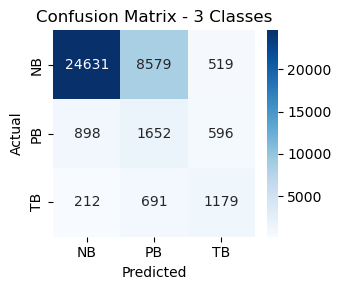


POST-CLASSIFICATION: PB + NB → NB

Grouped test distribution:
  TB (1)    : 2,082
  NB+PB (0) : 36,875

Grouped predictions:
  Predicted TB (1)    : 2,294
  Predicted NB+PB (0) : 36,663

EVALUATION 2: BINARY (TB vs PB+NB) - POST-CLASSIFICATION

Accuracy : 0.9482
Precision: 0.5139
Recall   : 0.5663
F1-Score : 0.5388

Confusion Matrix (TB vs PB+NB):
              Predicted
              TB    PB+NB
  Actual TB    1179     903
         PB+NB  1115   35760


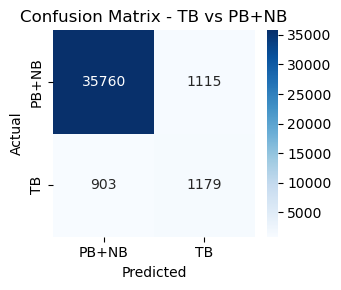


SUMMARY

Model Architecture: LSTM (hidden_size=24, num_layers=2)
Total parameters: 7,515

Evaluation 1 (3 classes: TB, PB, NB):
  Accuracy: 0.7049
  Performance drop: 0.0562 (5.62%)

Evaluation 2 (Binary: TB vs PB+NB) - POST-CLASSIFICATION:
  Accuracy : 0.9482
  Precision: 0.5139
  Recall   : 0.5663
  F1-Score : 0.5388

Test distribution (original):
  TB     : 2,082
  PB     : 3,146
  NB     : 33,729

Test distribution (grouped):
  TB     : 2,082
  PB+NB  : 36,875

GENERALIZATION COMPLETE


In [11]:
# ============================================
# LSTM LINEAR GENERALIZATION (2022)
# ============================================

import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import warnings
import os

# ----------------------------------------------------------------------------
# SUPPRESS WARNINGS
# ----------------------------------------------------------------------------

warnings.filterwarnings('ignore')

# ----------------------------------------------------------------------------
# GPU CONFIGURATION
# ----------------------------------------------------------------------------

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

BATCH_SIZE = 64

# ----------------------------------------------------------------------------
# 1. DEFINE LSTM MODEL
# ----------------------------------------------------------------------------

class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=24, num_layers=2, num_classes=3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.bn1 = nn.BatchNorm1d(hidden_size)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.bn1(out)
        out = self.dropout(out)
        out = self.fc(out)
        return out

# ----------------------------------------------------------------------------
# 2. LOAD TRAINED MODEL
# ----------------------------------------------------------------------------

print("=" * 60)
print("LSTM LINEAR - 2022 GENERALIZATION")
print("=" * 60)

model_dir = '/home/jovyan/ScienceDB/LSTM/Linear'
checkpoint = torch.load(
    os.path.join(model_dir, 'lstm_model.pth'),
    map_location=device,
    weights_only=False
)

model = LSTMModel(input_size=1, hidden_size=24, num_layers=2, num_classes=3).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

metadata = checkpoint['metadata']
feature_names = checkpoint['feature_cols']
scaler = checkpoint['scaler']
label_mapping = checkpoint.get('label_mapping', {'nb': 0, 'pb': 1, 'tb': 2})

print("\nModel loaded:")
print(f"  Trained on       : {metadata['train_years']}")
print(f"  Val Accuracy     : {metadata['accuracy_3classes']:.4f}")
print(f"  Features         : {len(feature_names):,}")
print(f"  Hidden size      : {metadata.get('hidden_size', 24)}")
print(f"  Num layers       : {metadata.get('num_layers', 2)}")
print(f"  Total parameters : {metadata.get('total_parameters', 'N/A'):,}")
print(f"  Epochs trained   : {metadata.get('epochs_trained', 'N/A')}")
print(f"  Classes          : {metadata['classes']}")

# ----------------------------------------------------------------------------
# 3. PREPARE TEST DATA (2022)
# ----------------------------------------------------------------------------

print("\n" + "=" * 60)
print("PREPARING TEST DATA (2022)")
print("=" * 60)

def remove_year_prefix_2022(col_name):
    """Remove '22' prefix from 2022 column names."""
    if col_name.startswith(('d_22', 'g_22', 'i_22')):
        return col_name[:2] + '_' + col_name[4:]
    return col_name

parquet_path = "/home/jovyan/ScienceDB/Dataset/Dataset_WFI.parquet"

# Load 2022 data
df = pd.read_parquet(
    parquet_path,
    columns=['22_labels'] + [col for col in pd.read_parquet(parquet_path).columns 
                             if col.startswith(('d_22', 'g_22', 'i_22'))]
)

# Filter for all 3 classes
df_2022 = df[df['22_labels'].isin(['tb', 'pb', 'nb'])].copy()

# Rename columns
rename_mapping = {col: remove_year_prefix_2022(col) for col in df_2022.columns 
                  if col.startswith(('d_22', 'g_22', 'i_22'))}
df_2022_renamed = df_2022.rename(columns=rename_mapping)

print(f"Samples: {len(df_2022_renamed):,}")
print(f"  TB: {sum(df_2022_renamed['22_labels'] == 'tb'):,}")
print(f"  PB: {sum(df_2022_renamed['22_labels'] == 'pb'):,}")
print(f"  NB: {sum(df_2022_renamed['22_labels'] == 'nb'):,}")

# ----------------------------------------------------------------------------
# 4. BATCH PREDICTION FUNCTION
# ----------------------------------------------------------------------------

def predict_in_batches(model, df, feature_names, scaler, batch_size=BATCH_SIZE):
    """Make predictions in batches to avoid memory overflow."""
    model.eval()
    all_preds = []
    all_probas = []
    
    total_samples = len(df)
    print(f"\nProcessing {total_samples:,} samples in batches of {batch_size}...")
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        for start_idx in range(0, total_samples, batch_size):
            end_idx = min(start_idx + batch_size, total_samples)
            batch_df = df.iloc[start_idx:end_idx]
            
            # Prepare features
            X_batch = np.zeros((len(batch_df), len(feature_names)), dtype=np.float32)
            for i, col in enumerate(feature_names):
                if col in batch_df.columns:
                    X_batch[:, i] = batch_df[col].values.astype(np.float32)
                # Missing features filled with 0
            
            # Scale and reshape
            X_batch_scaled = scaler.transform(X_batch)
            X_batch_reshaped = X_batch_scaled.reshape(
                X_batch_scaled.shape[0], X_batch_scaled.shape[1], 1
            )
            X_tensor = torch.FloatTensor(X_batch_reshaped).to(device)
            
            # Predict
            with torch.no_grad():
                batch_logits = model(X_tensor)
                batch_probas = torch.softmax(batch_logits, dim=1).cpu().numpy()
                batch_preds = torch.argmax(batch_logits, dim=1).cpu().numpy()
            
            all_probas.extend(batch_probas)
            all_preds.extend(batch_preds)
            
            # Clean GPU memory
            del X_tensor, X_batch, X_batch_scaled, X_batch_reshaped
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            
            if (start_idx // batch_size) % 10 == 0 and start_idx > 0:
                print(f"  Processed {end_idx:,}/{total_samples:,} samples")
    
    return np.array(all_preds), np.array(all_probas)

# ----------------------------------------------------------------------------
# 5. MAKE PREDICTIONS
# ----------------------------------------------------------------------------

print("\n" + "=" * 60)
print("PREDICTING ON 2022 DATA")
print("=" * 60)

y_test = df_2022_renamed['22_labels'].values
y_test_encoded = np.array([label_mapping[label] for label in y_test])

y_pred, y_pred_proba = predict_in_batches(
    model, df_2022_renamed, feature_names, scaler
)

print(f"\nPredictions distribution:")
print(f"  Predicted TB: {sum(y_pred == 2):,} ({sum(y_pred == 2)/len(y_pred)*100:.1f}%)")
print(f"  Predicted PB: {sum(y_pred == 1):,} ({sum(y_pred == 1)/len(y_pred)*100:.1f}%)")
print(f"  Predicted NB: {sum(y_pred == 0):,} ({sum(y_pred == 0)/len(y_pred)*100:.1f}%)")

# ----------------------------------------------------------------------------
# 6. EVALUATION 1: 3 CLASSES
# ----------------------------------------------------------------------------

print("\n" + "=" * 60)
print("EVALUATION 1: 3 CLASSES (TB, PB, NB)")
print("=" * 60)

accuracy_3classes = accuracy_score(y_test_encoded, y_pred)
performance_drop_3classes = metadata['accuracy_3classes'] - accuracy_3classes

print(f"\nAccuracy: {accuracy_3classes:.4f}")
print(f"Performance drop: {performance_drop_3classes:.4f} "
      f"({performance_drop_3classes * 100:.2f}%)")

print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred, 
                           target_names=['NB', 'PB', 'TB'],
                           labels=[0, 1, 2]))

# Confusion Matrix - 3 classes
plt.figure(figsize=(3.5, 3))
cm_3 = confusion_matrix(y_test_encoded, y_pred, labels=[0, 1, 2])
sns.heatmap(cm_3, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NB', 'PB', 'TB'], 
            yticklabels=['NB', 'PB', 'TB'])
plt.title('Confusion Matrix - 3 Classes', fontsize=12)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# 7. POST-CLASSIFICATION: GROUP PB+NB AS NB
# ----------------------------------------------------------------------------

print("\n" + "=" * 60)
print("POST-CLASSIFICATION: PB + NB → NB")
print("=" * 60)

y_test_grouped = np.array([0 if l in [0, 1] else 1 for l in y_test_encoded])
y_pred_grouped = np.array([0 if l in [0, 1] else 1 for l in y_pred])

print(f"\nGrouped test distribution:")
print(f"  TB (1)    : {sum(y_test_grouped == 1):,}")
print(f"  NB+PB (0) : {sum(y_test_grouped == 0):,}")

print(f"\nGrouped predictions:")
print(f"  Predicted TB (1)    : {sum(y_pred_grouped == 1):,}")
print(f"  Predicted NB+PB (0) : {sum(y_pred_grouped == 0):,}")

# ----------------------------------------------------------------------------
# 8. EVALUATION 2: BINARY (TB vs PB+NB)
# ----------------------------------------------------------------------------

print("\n" + "=" * 60)
print("EVALUATION 2: BINARY (TB vs PB+NB) - POST-CLASSIFICATION")
print("=" * 60)

accuracy_binary = accuracy_score(y_test_grouped, y_pred_grouped)

# Calculate metrics
tp = np.sum((y_test_grouped == 1) & (y_pred_grouped == 1))
tn = np.sum((y_test_grouped == 0) & (y_pred_grouped == 0))
fp = np.sum((y_test_grouped == 0) & (y_pred_grouped == 1))
fn = np.sum((y_test_grouped == 1) & (y_pred_grouped == 0))

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nAccuracy : {accuracy_binary:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

print(f"\nConfusion Matrix (TB vs PB+NB):")
print(f"              Predicted")
print(f"              TB    PB+NB")
print(f"  Actual TB   {tp:>5}   {fn:>5}")
print(f"         PB+NB {fp:>5}   {tn:>5}")

# Confusion Matrix - 2 classes
plt.figure(figsize=(3.5, 3))
cm_2 = confusion_matrix(y_test_grouped, y_pred_grouped)
sns.heatmap(cm_2, annot=True, fmt='d', cmap='Blues',
            xticklabels=['PB+NB', 'TB'], 
            yticklabels=['PB+NB', 'TB'])
plt.title('Confusion Matrix - TB vs PB+NB', fontsize=12)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# 9. SUMMARY
# ----------------------------------------------------------------------------

print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"\nModel Architecture: LSTM (hidden_size=24, num_layers=2)")
print(f"Total parameters: {metadata.get('total_parameters', 'N/A'):,}")

print(f"\nEvaluation 1 (3 classes: TB, PB, NB):")
print(f"  Accuracy: {accuracy_3classes:.4f}")
print(f"  Performance drop: {performance_drop_3classes:.4f} "
      f"({performance_drop_3classes * 100:.2f}%)")

print(f"\nEvaluation 2 (Binary: TB vs PB+NB) - POST-CLASSIFICATION:")
print(f"  Accuracy : {accuracy_binary:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall   : {recall:.4f}")
print(f"  F1-Score : {f1:.4f}")

print(f"\nTest distribution (original):")
print(f"  TB     : {sum(y_test_encoded == 2):,}")
print(f"  PB     : {sum(y_test_encoded == 1):,}")
print(f"  NB     : {sum(y_test_encoded == 0):,}")

print(f"\nTest distribution (grouped):")
print(f"  TB     : {sum(y_test_grouped == 1):,}")
print(f"  PB+NB  : {sum(y_test_grouped == 0):,}")

print("\n" + "=" * 60)
print("GENERALIZATION COMPLETE")
print("=" * 60)

**Training with LSTM coupled**

Using device: cuda
GPU: Tesla V100-SXM2-16GB
LSTM COUPLED TRAINING
Loaded 38,957 rows with 2,192 columns
2020 samples: 38,957
2021 samples: 38,957

Combined dataset: 77,914 samples
  TB: 4,618
  PB: 4,935
  NB: 68,361

Balancing to 4,618 samples per class

Balanced dataset: 13,854 samples
  TB: 4,618
  PB: 4,618
  NB: 4,618

Columns per feature type:
  d_ (NDVI): 365
  g_ (GEMI) : 365
  i_ (NDWI) : 365

Coupled features shape: (13854, 365, 3)

Class distribution:
  NB: 4,618
  PB: 4,618
  TB: 4,618

X_scaled shape: (13854, 365, 3)

Training set: 11,083 samples
Test set    : 2,771 samples
Timesteps   : 365 (days)
Features    : 3 per timestep
LSTMCoupledModel(
  (lstm): LSTM(3, 24, num_layers=2, batch_first=True)
  (bn1): BatchNorm1d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=24, out_features=3, bias=True)
)

Total parameters: 7,707

Training LSTM Coupled (3 classes: TB, PB, NB)...
Architecture

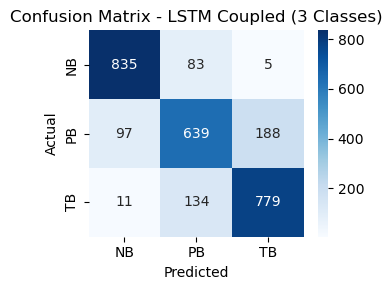

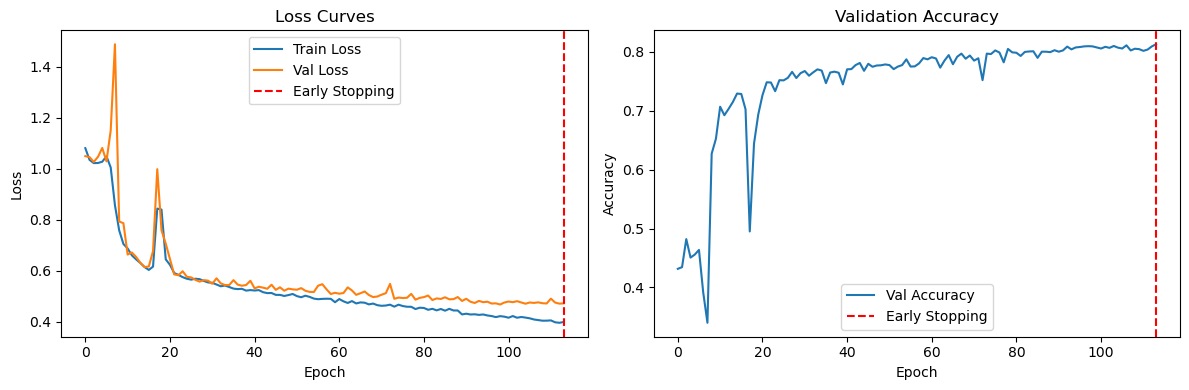


LSTM COUPLED TRAINING COMPLETE
Device           : cuda
Timesteps        : 365 (365 days)
Features per step: 3 (d_, g_, i_)
Hidden size      : 24
Num layers       : 2
Total parameters : 7,707
Epochs trained   : 114
Accuracy (3 cls) : 0.8131
Best val loss    : 0.4669
Models saved to  : /home/jovyan/ScienceDB/LSTM/Coupled


In [12]:
# ============================================
# LSTM COUPLED TRAINING (3 CLASSES)
# ============================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import warnings
import os

# ----------------------------------------------------------------------------
# SUPPRESS WARNINGS
# ----------------------------------------------------------------------------

warnings.filterwarnings('ignore')

# ----------------------------------------------------------------------------
# GPU CONFIGURATION
# ----------------------------------------------------------------------------

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("GPU not available, using CPU")

# Set seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# ----------------------------------------------------------------------------
# UTILITY FUNCTIONS
# ----------------------------------------------------------------------------

def remove_year_prefix(col_name):
    """Remove year prefix from column names."""
    for prefix in ['d_20', 'd_21', 'g_20', 'g_21', 'i_20', 'i_21']:
        if col_name.startswith(prefix):
            return prefix[:2] + '_' + col_name[4:]
    return col_name

# ----------------------------------------------------------------------------
# 1. LOAD AND PREPARE DATA
# ----------------------------------------------------------------------------

print("=" * 60)
print("LSTM COUPLED TRAINING")
print("=" * 60)

parquet_path = "/home/jovyan/ScienceDB/Dataset/Dataset_WFI.parquet"

# Load column names
columns = pd.read_parquet(parquet_path).head(0).columns

# Get features for both years
features_2020 = [col for col in columns if col.startswith(('d_20', 'g_20', 'i_20'))]
features_2021 = [col for col in columns if col.startswith(('d_21', 'g_21', 'i_21'))]

# Load data
df = pd.read_parquet(
    parquet_path,
    columns=features_2020 + features_2021 + ['20_labels', '21_labels']
)
print(f"Loaded {len(df):,} rows with {len(df.columns):,} columns")

# ----------------------------------------------------------------------------
# 2. PREPARE COMBINED DATASET
# ----------------------------------------------------------------------------

def prepare_year_data(df, feature_cols, label_col):
    """Extract and rename features for a specific year."""
    df_year = df[feature_cols + [label_col]].copy()
    
    # Remove year prefix from feature names
    rename_mapping = {col: remove_year_prefix(col) for col in feature_cols}
    df_year = df_year.rename(columns=rename_mapping)
    df_year = df_year.rename(columns={label_col: 'label'})
    
    return df_year

# Prepare each year
df_2020 = prepare_year_data(df, features_2020, '20_labels')
df_2021 = prepare_year_data(df, features_2021, '21_labels')

print(f"2020 samples: {len(df_2020):,}")
print(f"2021 samples: {len(df_2021):,}")

# Combine years
df_combined = pd.concat([df_2020, df_2021], ignore_index=True)

print(f"\nCombined dataset: {len(df_combined):,} samples")
print(f"  TB: {len(df_combined[df_combined['label'] == 'tb']):,}")
print(f"  PB: {len(df_combined[df_combined['label'] == 'pb']):,}")
print(f"  NB: {len(df_combined[df_combined['label'] == 'nb']):,}")

# ----------------------------------------------------------------------------
# 3. BALANCE DATASET (3 Classes)
# ----------------------------------------------------------------------------

tb = df_combined[df_combined['label'] == 'tb']
pb = df_combined[df_combined['label'] == 'pb']
nb = df_combined[df_combined['label'] == 'nb']

min_samples = min(len(tb), len(pb), len(nb))
print(f"\nBalancing to {min_samples:,} samples per class")

tb_sampled = tb.sample(n=min_samples, random_state=42)
pb_sampled = pb.sample(n=min_samples, random_state=42)
nb_sampled = nb.sample(n=min_samples, random_state=42)

df_balanced = pd.concat([tb_sampled, pb_sampled, nb_sampled])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nBalanced dataset: {len(df_balanced):,} samples")
print(f"  TB: {len(df_balanced[df_balanced['label'] == 'tb']):,}")
print(f"  PB: {len(df_balanced[df_balanced['label'] == 'pb']):,}")
print(f"  NB: {len(df_balanced[df_balanced['label'] == 'nb']):,}")

# ----------------------------------------------------------------------------
# 4. PREPARE COUPLED FEATURES (365 days × 3 features)
# ----------------------------------------------------------------------------

# Get d_, g_, i_ columns
d_cols = sorted([col for col in df_balanced.columns if col.startswith('d_')])
g_cols = sorted([col for col in df_balanced.columns if col.startswith('g_')])
i_cols = sorted([col for col in df_balanced.columns if col.startswith('i_')])

print(f"\nColumns per feature type:")
print(f"  d_ (NDVI): {len(d_cols):,}")
print(f"  g_ (GEMI) : {len(g_cols):,}")
print(f"  i_ (NDWI) : {len(i_cols):,}")

# Create coupled features: (samples, 365, 3)
coupled_features = []
for d_col, g_col, i_col in zip(d_cols, g_cols, i_cols):
    day_features = np.column_stack([
        df_balanced[d_col].values,
        df_balanced[g_col].values,
        df_balanced[i_col].values
    ])
    coupled_features.append(day_features)

X_coupled = np.stack(coupled_features, axis=1)
print(f"\nCoupled features shape: {X_coupled.shape}")  # (samples, 365, 3)

# ----------------------------------------------------------------------------
# 5. LABELS
# ----------------------------------------------------------------------------

y = df_balanced['label']
label_mapping = {'nb': 0, 'pb': 1, 'tb': 2}
y_encoded = np.array([label_mapping[label] for label in y])

print(f"\nClass distribution:")
print(f"  NB: {sum(y_encoded == 0):,}")
print(f"  PB: {sum(y_encoded == 1):,}")
print(f"  TB: {sum(y_encoded == 2):,}")

# ----------------------------------------------------------------------------
# 6. STANDARDIZE DATA
# ----------------------------------------------------------------------------

# Reshape to 2D for scaling: (samples * days, 3)
X_flat = X_coupled.reshape(-1, 3)
scaler = StandardScaler()
X_flat_scaled = scaler.fit_transform(X_flat)

# Reshape back to (samples, days, 3)
X_scaled = X_flat_scaled.reshape(X_coupled.shape)
print(f"\nX_scaled shape: {X_scaled.shape}")

# ----------------------------------------------------------------------------
# 7. TRAIN-TEST SPLIT
# ----------------------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\nTraining set: {len(X_train):,} samples")
print(f"Test set    : {len(X_test):,} samples")
print(f"Timesteps   : {X_train.shape[1]} (days)")
print(f"Features    : {X_train.shape[2]} per timestep")

# ----------------------------------------------------------------------------
# 8. CONVERT TO PYTORCH TENSORS
# ----------------------------------------------------------------------------

X_train_tensor = torch.FloatTensor(X_train).to(device)
X_test_tensor = torch.FloatTensor(X_test).to(device)
y_train_tensor = torch.LongTensor(y_train).to(device)
y_test_tensor = torch.LongTensor(y_test).to(device)

batch_size = 32
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# ----------------------------------------------------------------------------
# 9. DEFINE LSTM COUPLED MODEL (Optimized - ~3K parameters)
# ----------------------------------------------------------------------------

class LSTMCoupledModel(nn.Module):
    def __init__(self, input_size=3, hidden_size=24, num_layers=2, num_classes=3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.bn1 = nn.BatchNorm1d(hidden_size)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]  # Take last timestep
        out = self.bn1(out)
        out = self.dropout(out)
        out = self.fc(out)
        return out

model = LSTMCoupledModel(input_size=3, hidden_size=24, num_layers=2, num_classes=3).to(device)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

# ----------------------------------------------------------------------------
# 10. EARLY STOPPING
# ----------------------------------------------------------------------------

class EarlyStopping:
    def __init__(self, patience=15, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        
    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

# ----------------------------------------------------------------------------
# 11. TRAIN LSTM
# ----------------------------------------------------------------------------

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=5)

early_stopping = EarlyStopping(patience=15, min_delta=0.0005)

print("\nTraining LSTM Coupled (3 classes: TB, PB, NB)...")
print(f"Architecture: hidden_size=24, num_layers=2")

n_epochs = 200
train_losses = []
val_losses = []
val_accuracies = []
best_val_loss = float('inf')

for epoch in range(n_epochs):
    # Training
    model.train()
    epoch_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        y_pred = model(batch_X)
        loss = criterion(y_pred, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validation
    model.eval()
    with torch.no_grad():
        y_val_pred = model(X_test_tensor)
        val_loss = criterion(y_val_pred, y_test_tensor)
        val_losses.append(val_loss.item())
        
        y_val_pred_classes = torch.argmax(y_val_pred, dim=1)
        val_acc = (y_val_pred_classes == y_test_tensor).float().mean().item()
        val_accuracies.append(val_acc)
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict().copy()
    
    scheduler.step(val_loss)
    early_stopping(val_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{n_epochs} - Train Loss: {avg_train_loss:.4f}, "
              f"Val Loss: {val_loss.item():.4f}, Val Acc: {val_acc:.4f}")
    
    if early_stopping.early_stop:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

model.load_state_dict(best_model_state)
print(f"\nBest validation loss: {best_val_loss:.4f}")

# ----------------------------------------------------------------------------
# 12. EVALUATE
# ----------------------------------------------------------------------------

model.eval()
with torch.no_grad():
    y_pred_logits = model(X_test_tensor)
    y_pred = torch.argmax(y_pred_logits, dim=1).cpu().numpy()

y_test_labels = np.array(['nb' if l == 0 else 'pb' if l == 1 else 'tb' for l in y_test])
y_pred_labels = np.array(['nb' if l == 0 else 'pb' if l == 1 else 'tb' for l in y_pred])

accuracy = accuracy_score(y_test, y_pred)

print("\n" + "=" * 60)
print("MODEL EVALUATION")
print("=" * 60)
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_labels, y_pred_labels, target_names=['NB', 'PB', 'TB']))

# Confusion Matrix
plt.figure(figsize=(3.5, 3))
cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NB', 'PB', 'TB'], 
            yticklabels=['NB', 'PB', 'TB'])
plt.title('Confusion Matrix - LSTM Coupled (3 Classes)', fontsize=12)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Val Loss')
ax1.axvline(x=len(train_losses)-1, color='red', linestyle='--', label='Early Stopping')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.set_title('Loss Curves')

ax2.plot(val_accuracies, label='Val Accuracy')
ax2.axvline(x=len(val_accuracies)-1, color='red', linestyle='--', label='Early Stopping')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.set_title('Validation Accuracy')

plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# 13. SAVE MODEL
# ----------------------------------------------------------------------------

save_dir = '/home/jovyan/ScienceDB/LSTM/Coupled'
os.makedirs(save_dir, exist_ok=True)

# Save PyTorch model
torch.save({
    'model_state_dict': model.state_dict(),
    'feature_cols': ['d', 'g', 'i'],
    'scaler': scaler,
    'label_mapping': label_mapping,
    'metadata': {
        'model_type': 'LSTM Coupled (PyTorch) - Optimized',
        'train_years': [2020, 2021],
        'approach': 'coupled_3classes',
        'timesteps': X_train.shape[1],
        'features_per_timestep': X_train.shape[2],
        'features_names': ['d_', 'g_', 'i_'],
        'num_classes': 3,
        'classes': ['nb', 'pb', 'tb'],
        'hidden_size': 24,
        'num_layers': 2,
        'total_parameters': sum(p.numel() for p in model.parameters()),
        'accuracy_3classes': accuracy,
        'best_val_loss': best_val_loss,
        'epochs_trained': len(train_losses)
    }
}, os.path.join(save_dir, 'lstm_model_3classes_coupled.pth'))

# Save scaler and label mapping
joblib.dump(scaler, os.path.join(save_dir, 'scaler_lstm_coupled.pkl'))
joblib.dump(label_mapping, os.path.join(save_dir, 'label_mapping_coupled.pkl'))

print("\n" + "=" * 50)
print("LSTM COUPLED TRAINING COMPLETE")
print("=" * 50)
print(f"Device           : {device}")
print(f"Timesteps        : {X_train.shape[1]} (365 days)")
print(f"Features per step: {X_train.shape[2]} (d_, g_, i_)")
print(f"Hidden size      : 24")
print(f"Num layers       : 2")
print(f"Total parameters : {sum(p.numel() for p in model.parameters()):,}")
print(f"Epochs trained   : {len(train_losses)}")
print(f"Accuracy (3 cls) : {accuracy:.4f}")
print(f"Best val loss    : {best_val_loss:.4f}")
print(f"Models saved to  : {save_dir}")

**Generalization with LSTM coupld**

Using device: cuda
GPU: Tesla V100-SXM2-16GB
LSTM COUPLED - 2022 GENERALIZATION

Model loaded:
  Trained on       : [2020, 2021]
  Val Accuracy     : 0.8131
  Approach         : coupled_3classes
  Timesteps        : 365 (days)
  Features per step: 3 (d_, g_, i_)
  Hidden size      : 24
  Num layers       : 2
  Total parameters : 7,707
  Epochs trained   : 114
  Classes          : ['nb', 'pb', 'tb']

PREPARING TEST DATA (2022)
Loaded 38,957 rows with 1,096 columns

Columns per feature type:
  d_ (NDVI): 365
  g_ (GEMI) : 365
  i_ (NDWI) : 365

X_coupled_2022 shape: (38957, 365, 3)

Test data (2022):
  Samples: 38,957
  TB: 2,082 (5.3%)
  PB: 3,146 (8.1%)
  NB: 33,729 (86.6%)
  X_test shape: (38957, 365, 3)
  Timesteps   : 365
  Features    : 3 per timestep

PREDICTING ON 2022 DATA
Processing 38,957 samples in batches of 64...
  Processed 704/38,957 samples
  Processed 1,344/38,957 samples
  Processed 1,984/38,957 samples
  Processed 2,624/38,957 samples
  Processed 3,264/38,957 samples


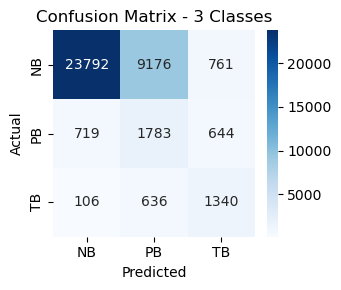


POST-CLASSIFICATION: PB + NB → NB

Grouped test distribution:
  TB (1)    : 2,082
  NB+PB (0) : 36,875

Grouped predictions:
  Predicted TB (1)    : 2,745
  Predicted NB+PB (0) : 36,212

EVALUATION 2: BINARY (TB vs PB+NB) - POST-CLASSIFICATION

Accuracy : 0.9449
Precision: 0.4882
Recall   : 0.6436
F1-Score : 0.5552

Confusion Matrix (TB vs PB+NB):
              Predicted
              TB    PB+NB
  Actual TB    1340     742
         PB+NB  1405   35470


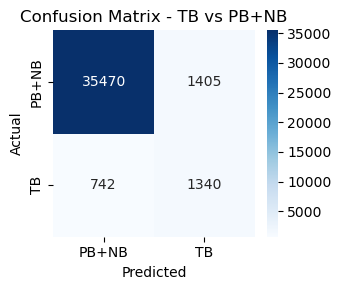


SUMMARY

Model Architecture: LSTM Coupled (hidden_size=24, num_layers=2)
Total parameters: 7,707

Evaluation 1 (3 classes: TB, PB, NB):
  Accuracy: 0.6909
  Performance drop: 0.1222 (12.22%)

Evaluation 2 (Binary: TB vs PB+NB) - POST-CLASSIFICATION:
  Accuracy : 0.9449
  Precision: 0.4882
  Recall   : 0.6436
  F1-Score : 0.5552

Test distribution:
  TB     : 2,082
  PB     : 3,146
  NB     : 33,729
  PB+NB  : 36,875

GENERALIZATION COMPLETE


In [13]:
# ============================================
# LSTM COUPLED GENERALIZATION (2022)
# ============================================

import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import warnings
import os

# ----------------------------------------------------------------------------
# SUPPRESS WARNINGS
# ----------------------------------------------------------------------------

warnings.filterwarnings('ignore')

# ----------------------------------------------------------------------------
# GPU CONFIGURATION
# ----------------------------------------------------------------------------

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("GPU not available, using CPU")

# ----------------------------------------------------------------------------
# UTILITY FUNCTIONS
# ----------------------------------------------------------------------------

def remove_year_prefix(col_name):
    """Remove year prefix from column names."""
    for prefix in ['d_20', 'd_21', 'd_22', 'g_20', 'g_21', 'g_22', 'i_20', 'i_21', 'i_22']:
        if col_name.startswith(prefix):
            return prefix[:2] + '_' + col_name[4:]
    return col_name

# ----------------------------------------------------------------------------
# 1. DEFINE LSTM COUPLED MODEL
# ----------------------------------------------------------------------------

class LSTMCoupledModel(nn.Module):
    def __init__(self, input_size=3, hidden_size=24, num_layers=2, num_classes=3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.bn1 = nn.BatchNorm1d(hidden_size)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.bn1(out)
        out = self.dropout(out)
        out = self.fc(out)
        return out

# ----------------------------------------------------------------------------
# 2. LOAD TRAINED MODEL
# ----------------------------------------------------------------------------

print("=" * 60)
print("LSTM COUPLED - 2022 GENERALIZATION")
print("=" * 60)

model_dir = '/home/jovyan/ScienceDB/LSTM/Coupled'
checkpoint = torch.load(
    os.path.join(model_dir, 'lstm_model_3classes_coupled.pth'),
    map_location=device,
    weights_only=False
)

model = LSTMCoupledModel(input_size=3, hidden_size=24, num_layers=2, num_classes=3).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

metadata = checkpoint['metadata']
scaler = checkpoint['scaler']
label_mapping = checkpoint.get('label_mapping', {'nb': 0, 'pb': 1, 'tb': 2})

print("\nModel loaded:")
print(f"  Trained on       : {metadata['train_years']}")
print(f"  Val Accuracy     : {metadata['accuracy_3classes']:.4f}")
print(f"  Approach         : {metadata['approach']}")
print(f"  Timesteps        : {metadata['timesteps']} (days)")
print(f"  Features per step: {metadata['features_per_timestep']} (d_, g_, i_)")
print(f"  Hidden size      : {metadata.get('hidden_size', 24)}")
print(f"  Num layers       : {metadata.get('num_layers', 2)}")
print(f"  Total parameters : {metadata.get('total_parameters', 'N/A'):,}")
print(f"  Epochs trained   : {metadata.get('epochs_trained', 'N/A')}")
print(f"  Classes          : {metadata['classes']}")

# ----------------------------------------------------------------------------
# 3. PREPARE TEST DATA (2022)
# ----------------------------------------------------------------------------

print("\n" + "=" * 60)
print("PREPARING TEST DATA (2022)")
print("=" * 60)

parquet_path = "/home/jovyan/ScienceDB/Dataset/Dataset_WFI.parquet"

# Load 2022 data
df = pd.read_parquet(
    parquet_path,
    columns=['22_labels'] + [col for col in pd.read_parquet(parquet_path).columns 
                             if col.startswith(('d_22', 'g_22', 'i_22'))]
)

print(f"Loaded {len(df):,} rows with {len(df.columns):,} columns")

# Filter all three classes
df_2022 = df[df['22_labels'].isin(['tb', 'pb', 'nb'])].copy()

# Rename 2022 columns
rename_mapping = {col: remove_year_prefix(col) for col in df_2022.columns 
                  if col.startswith(('d_22', 'g_22', 'i_22'))}
df_2022_renamed = df_2022.rename(columns=rename_mapping)

# Get coupled features for 2022
d_cols_2022 = sorted([col for col in df_2022_renamed.columns if col.startswith('d_')])
g_cols_2022 = sorted([col for col in df_2022_renamed.columns if col.startswith('g_')])
i_cols_2022 = sorted([col for col in df_2022_renamed.columns if col.startswith('i_')])

print(f"\nColumns per feature type:")
print(f"  d_ (NDVI): {len(d_cols_2022):,}")
print(f"  g_ (GEMI) : {len(g_cols_2022):,}")
print(f"  i_ (NDWI) : {len(i_cols_2022):,}")

# Create coupled features: (samples, 365, 3)
coupled_features_2022 = []
for d_col, g_col, i_col in zip(d_cols_2022, g_cols_2022, i_cols_2022):
    day_features = np.column_stack([
        df_2022_renamed[d_col].values,
        df_2022_renamed[g_col].values,
        df_2022_renamed[i_col].values
    ])
    coupled_features_2022.append(day_features)

X_coupled_2022 = np.stack(coupled_features_2022, axis=1)
X_coupled_2022 = np.nan_to_num(X_coupled_2022, nan=0.0)

print(f"\nX_coupled_2022 shape: {X_coupled_2022.shape}")

# ----------------------------------------------------------------------------
# 4. STANDARDIZE DATA
# ----------------------------------------------------------------------------

X_flat_2022 = X_coupled_2022.reshape(-1, 3)
X_flat_scaled_2022 = scaler.transform(X_flat_2022)
X_scaled_2022 = X_flat_scaled_2022.reshape(X_coupled_2022.shape)

# Labels
y_test = df_2022_renamed['22_labels'].values
y_test_encoded = np.array([label_mapping[label] for label in y_test])

print(f"\nTest data (2022):")
print(f"  Samples: {len(X_scaled_2022):,}")
print(f"  TB: {sum(y_test_encoded == 2):,} ({sum(y_test_encoded == 2)/len(y_test_encoded)*100:.1f}%)")
print(f"  PB: {sum(y_test_encoded == 1):,} ({sum(y_test_encoded == 1)/len(y_test_encoded)*100:.1f}%)")
print(f"  NB: {sum(y_test_encoded == 0):,} ({sum(y_test_encoded == 0)/len(y_test_encoded)*100:.1f}%)")
print(f"  X_test shape: {X_scaled_2022.shape}")
print(f"  Timesteps   : {X_scaled_2022.shape[1]}")
print(f"  Features    : {X_scaled_2022.shape[2]} per timestep")

# ----------------------------------------------------------------------------
# 5. PREDICT ON 2022 (BATCH PROCESSING)
# ----------------------------------------------------------------------------

print("\n" + "=" * 60)
print("PREDICTING ON 2022 DATA")
print("=" * 60)

BATCH_SIZE = 64
total_samples = len(X_scaled_2022)
all_preds = []

print(f"Processing {total_samples:,} samples in batches of {BATCH_SIZE}...")

with torch.no_grad():
    for start_idx in range(0, total_samples, BATCH_SIZE):
        end_idx = min(start_idx + BATCH_SIZE, total_samples)
        
        X_batch = X_scaled_2022[start_idx:end_idx]
        X_tensor = torch.FloatTensor(X_batch).to(device)
        
        batch_logits = model(X_tensor)
        batch_preds = torch.argmax(batch_logits, dim=1).cpu().numpy()
        all_preds.extend(batch_preds)
        
        del X_tensor, X_batch
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        
        if (start_idx // BATCH_SIZE) % 10 == 0 and start_idx > 0:
            print(f"  Processed {end_idx:,}/{total_samples:,} samples")

y_pred = np.array(all_preds)

print(f"\nPredictions distribution (3 classes):")
print(f"  Predicted TB: {sum(y_pred == 2):,} ({sum(y_pred == 2)/len(y_pred)*100:.1f}%)")
print(f"  Predicted PB: {sum(y_pred == 1):,} ({sum(y_pred == 1)/len(y_pred)*100:.1f}%)")
print(f"  Predicted NB: {sum(y_pred == 0):,} ({sum(y_pred == 0)/len(y_pred)*100:.1f}%)")

# ----------------------------------------------------------------------------
# 6. EVALUATION 1: 3 CLASSES
# ----------------------------------------------------------------------------

print("\n" + "=" * 60)
print("EVALUATION 1: 3 CLASSES (TB, PB, NB)")
print("=" * 60)

accuracy_3classes = accuracy_score(y_test_encoded, y_pred)
performance_drop_3classes = metadata['accuracy_3classes'] - accuracy_3classes

print(f"\nAccuracy: {accuracy_3classes:.4f}")
print(f"Performance drop: {performance_drop_3classes:.4f} "
      f"({performance_drop_3classes * 100:.2f}%)")

print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred, 
                           target_names=['NB', 'PB', 'TB'],
                           labels=[0, 1, 2]))

# Confusion Matrix - 3 classes
plt.figure(figsize=(3.5, 3))
cm_3 = confusion_matrix(y_test_encoded, y_pred, labels=[0, 1, 2])
sns.heatmap(cm_3, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NB', 'PB', 'TB'], 
            yticklabels=['NB', 'PB', 'TB'])
plt.title('Confusion Matrix - 3 Classes', fontsize=12)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# 7. POST-CLASSIFICATION: GROUP PB+NB AS NB
# ----------------------------------------------------------------------------

print("\n" + "=" * 60)
print("POST-CLASSIFICATION: PB + NB → NB")
print("=" * 60)

y_test_grouped = np.array([0 if l in [0, 1] else 1 for l in y_test_encoded])
y_pred_grouped = np.array([0 if l in [0, 1] else 1 for l in y_pred])

print(f"\nGrouped test distribution:")
print(f"  TB (1)    : {sum(y_test_grouped == 1):,}")
print(f"  NB+PB (0) : {sum(y_test_grouped == 0):,}")

print(f"\nGrouped predictions:")
print(f"  Predicted TB (1)    : {sum(y_pred_grouped == 1):,}")
print(f"  Predicted NB+PB (0) : {sum(y_pred_grouped == 0):,}")

# ----------------------------------------------------------------------------
# 8. EVALUATION 2: BINARY (TB vs PB+NB)
# ----------------------------------------------------------------------------

print("\n" + "=" * 60)
print("EVALUATION 2: BINARY (TB vs PB+NB) - POST-CLASSIFICATION")
print("=" * 60)

accuracy_binary = accuracy_score(y_test_grouped, y_pred_grouped)

tp = np.sum((y_test_grouped == 1) & (y_pred_grouped == 1))
tn = np.sum((y_test_grouped == 0) & (y_pred_grouped == 0))
fp = np.sum((y_test_grouped == 0) & (y_pred_grouped == 1))
fn = np.sum((y_test_grouped == 1) & (y_pred_grouped == 0))

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nAccuracy : {accuracy_binary:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

print(f"\nConfusion Matrix (TB vs PB+NB):")
print(f"              Predicted")
print(f"              TB    PB+NB")
print(f"  Actual TB   {tp:>5}   {fn:>5}")
print(f"         PB+NB {fp:>5}   {tn:>5}")

# Confusion Matrix - 2 classes
plt.figure(figsize=(3.5, 3))
cm_2 = confusion_matrix(y_test_grouped, y_pred_grouped)
sns.heatmap(cm_2, annot=True, fmt='d', cmap='Blues',
            xticklabels=['PB+NB', 'TB'], 
            yticklabels=['PB+NB', 'TB'])
plt.title('Confusion Matrix - TB vs PB+NB', fontsize=12)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------
# 9. SUMMARY
# ----------------------------------------------------------------------------

print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"\nModel Architecture: LSTM Coupled (hidden_size=24, num_layers=2)")
print(f"Total parameters: {metadata.get('total_parameters', 'N/A'):,}")

print(f"\nEvaluation 1 (3 classes: TB, PB, NB):")
print(f"  Accuracy: {accuracy_3classes:.4f}")
print(f"  Performance drop: {performance_drop_3classes:.4f} "
      f"({performance_drop_3classes * 100:.2f}%)")

print(f"\nEvaluation 2 (Binary: TB vs PB+NB) - POST-CLASSIFICATION:")
print(f"  Accuracy : {accuracy_binary:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall   : {recall:.4f}")
print(f"  F1-Score : {f1:.4f}")

print(f"\nTest distribution:")
print(f"  TB     : {sum(y_test_encoded == 2):,}")
print(f"  PB     : {sum(y_test_encoded == 1):,}")
print(f"  NB     : {sum(y_test_encoded == 0):,}")
print(f"  PB+NB  : {sum(y_test_encoded != 2):,}")

print("\n" + "=" * 60)
print("GENERALIZATION COMPLETE")
print("=" * 60)

**Comparison and analysis**

Using device: cuda
SPATIAL VISUALIZATION

GeoPackage loaded: 38,957 geometries
CRS: EPSG:4326

Test samples: 38,957
  TB: 2,082
  PB: 3,146
  NB: 33,729

LOADING RANDOM FOREST

LOADING LSTM LINEAR

LOADING LSTM COUPLED

BINARY POST-PROCESSING (TB vs PB+NB)

BINARY METRICS (TB vs PB+NB)

Random Forest:
  TP: 919 | TN: 35352 | FP: 1522 | FN: 1163
  Accuracy: 0.9311 | Precision: 0.3765 | Recall: 0.4414 | F1: 0.4064
  IoU (TB): 0.2550 | IoU (PB+NB): 0.9294 | IoU (Global): 0.9311

LSTM Linear:
  TP: 1179 | TN: 35759 | FP: 1115 | FN: 903
  Accuracy: 0.9482 | Precision: 0.5139 | Recall: 0.5663 | F1: 0.5388
  IoU (TB): 0.3688 | IoU (PB+NB): 0.9466 | IoU (Global): 0.9482

LSTM Coupled:
  TP: 1340 | TN: 35469 | FP: 1405 | FN: 742
  Accuracy: 0.9449 | Precision: 0.4882 | Recall: 0.6436 | F1: 0.5552
  IoU (TB): 0.3843 | IoU (PB+NB): 0.9429 | IoU (Global): 0.9449

IoU SUMMARY TABLE
        Model  IoU (TB)  IoU (PB+NB)  IoU (Global)
Random Forest    0.2550       0.9294        0.9311
  LSTM Linear   

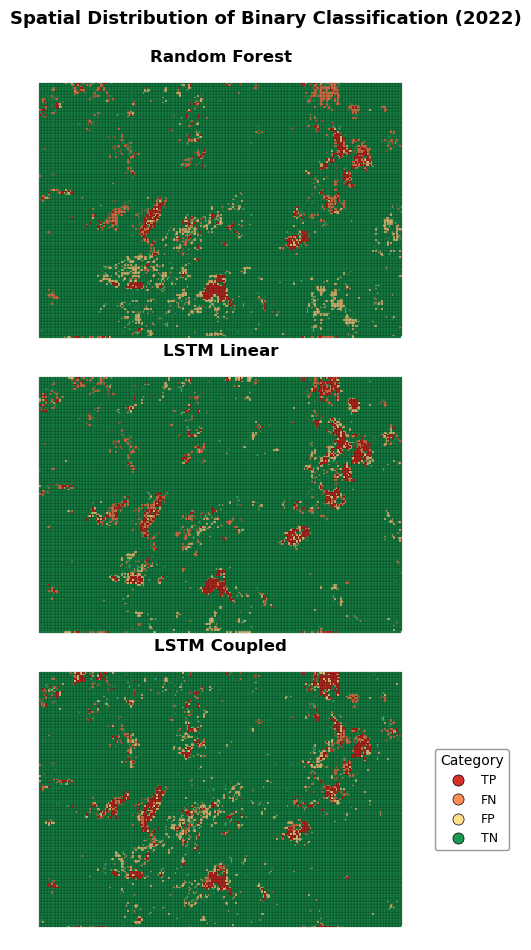


ANALYSIS COMPLETE


In [14]:
# ============================================
# SPATIAL VISUALIZATION & MODEL COMPARISON
# ============================================

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.metrics import confusion_matrix
import joblib
import torch
import torch.nn as nn
import warnings
import os

warnings.filterwarnings('ignore')

# ----------------------------------------------------------------------------
# GPU CONFIGURATION
# ----------------------------------------------------------------------------

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ----------------------------------------------------------------------------
# DEFINE MODELS
# ----------------------------------------------------------------------------

class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=24, num_layers=2, num_classes=3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.bn1 = nn.BatchNorm1d(hidden_size)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.bn1(out)
        out = self.dropout(out)
        out = self.fc(out)
        return out

class LSTMCoupledModel(nn.Module):
    def __init__(self, input_size=3, hidden_size=24, num_layers=2, num_classes=3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.bn1 = nn.BatchNorm1d(hidden_size)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.bn1(out)
        out = self.dropout(out)
        out = self.fc(out)
        return out

# ----------------------------------------------------------------------------
# UTILITY FUNCTIONS
# ----------------------------------------------------------------------------

def remove_year_prefix(col_name):
    """Remove year prefix from column names."""
    for prefix in ['d_20', 'd_21', 'd_22', 'g_20', 'g_21', 'g_22', 'i_20', 'i_21', 'i_22']:
        if col_name.startswith(prefix):
            return prefix[:2] + '_' + col_name[4:]
    return col_name

# ----------------------------------------------------------------------------
# LOAD GEOPACKAGE AND TEST DATA
# ----------------------------------------------------------------------------

print("=" * 60)
print("SPATIAL VISUALIZATION")
print("=" * 60)

parquet_path = "/home/jovyan/ScienceDB/Dataset/Dataset_WFI.parquet"
gpkg_path = "/home/jovyan/ScienceDB/Dataset/gpk_spatial_grid.gpkg"

# Load GeoPackage
gdf_original = gpd.read_file(gpkg_path)
print(f"\nGeoPackage loaded: {len(gdf_original):,} geometries")
print(f"CRS: {gdf_original.crs}")

# Load 2022 data
df = pd.read_parquet(
    parquet_path,
    columns=['22_labels'] + [col for col in pd.read_parquet(parquet_path).columns 
                             if col.startswith(('d_22', 'g_22', 'i_22'))]
)

df_2022 = df[df['22_labels'].isin(['tb', 'pb', 'nb'])].copy()
rename_mapping = {col: remove_year_prefix(col) for col in df_2022.columns 
                  if col.startswith(('d_22', 'g_22', 'i_22'))}
df_2022_renamed = df_2022.rename(columns=rename_mapping)

# Get IDs and labels
ids = df_2022_renamed['id'].values if 'id' in df_2022_renamed.columns else np.arange(len(df_2022_renamed))
y_test = df_2022_renamed['22_labels'].values

print(f"\nTest samples: {len(y_test):,}")
print(f"  TB: {sum(y_test == 'tb'):,}")
print(f"  PB: {sum(y_test == 'pb'):,}")
print(f"  NB: {sum(y_test == 'nb'):,}")

# ----------------------------------------------------------------------------
# 1. RANDOM FOREST PREDICTIONS
# ----------------------------------------------------------------------------

print("\n" + "=" * 60)
print("LOADING RANDOM FOREST")
print("=" * 60)

model_dir = '/home/jovyan/ScienceDB/RF'
rf_model = joblib.load(os.path.join(model_dir, 'random_forest_model.pkl'))
rf_feature_names = joblib.load(os.path.join(model_dir, 'feature_names.pkl'))

X_test_rf = np.zeros((len(df_2022_renamed), len(rf_feature_names)), dtype=np.float32)
for i, col in enumerate(rf_feature_names):
    if col in df_2022_renamed.columns:
        X_test_rf[:, i] = df_2022_renamed[col].values.astype(np.float32)

y_pred_rf = rf_model.predict(X_test_rf)

# ----------------------------------------------------------------------------
# 2. LSTM LINEAR PREDICTIONS
# ----------------------------------------------------------------------------

print("\n" + "=" * 60)
print("LOADING LSTM LINEAR")
print("=" * 60)

model_dir = '/home/jovyan/ScienceDB/LSTM/Linear'
checkpoint_linear = torch.load(
    os.path.join(model_dir, 'lstm_model.pth'),
    map_location=device,
    weights_only=False
)

model_linear = LSTMModel(input_size=1, hidden_size=24, num_layers=2, num_classes=3).to(device)
model_linear.load_state_dict(checkpoint_linear['model_state_dict'])
model_linear.eval()

feature_names_linear = checkpoint_linear['feature_cols']
scaler_linear = checkpoint_linear['scaler']

X_test_linear = np.zeros((len(df_2022_renamed), len(feature_names_linear)), dtype=np.float32)
for i, col in enumerate(feature_names_linear):
    if col in df_2022_renamed.columns:
        X_test_linear[:, i] = df_2022_renamed[col].values.astype(np.float32)

X_test_linear_scaled = scaler_linear.transform(X_test_linear)
X_test_linear_reshaped = X_test_linear_scaled.reshape(
    X_test_linear_scaled.shape[0], X_test_linear_scaled.shape[1], 1
)

BATCH_SIZE = 64
all_preds_linear = []
with torch.no_grad():
    for start_idx in range(0, len(X_test_linear_reshaped), BATCH_SIZE):
        end_idx = min(start_idx + BATCH_SIZE, len(X_test_linear_reshaped))
        X_batch = X_test_linear_reshaped[start_idx:end_idx]
        X_tensor = torch.FloatTensor(X_batch).to(device)
        batch_logits = model_linear(X_tensor)
        batch_preds = torch.argmax(batch_logits, dim=1).cpu().numpy()
        all_preds_linear.extend(batch_preds)
        del X_tensor, X_batch
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

y_pred_linear = np.array(all_preds_linear)
y_pred_linear_labels = np.array(['nb' if l == 0 else 'pb' if l == 1 else 'tb' for l in y_pred_linear])

# ----------------------------------------------------------------------------
# 3. LSTM COUPLED PREDICTIONS
# ----------------------------------------------------------------------------

print("\n" + "=" * 60)
print("LOADING LSTM COUPLED")
print("=" * 60)

model_dir = '/home/jovyan/ScienceDB/LSTM/Coupled'
checkpoint_coupled = torch.load(
    os.path.join(model_dir, 'lstm_model_3classes_coupled.pth'),
    map_location=device,
    weights_only=False
)

model_coupled = LSTMCoupledModel(input_size=3, hidden_size=24, num_layers=2, num_classes=3).to(device)
model_coupled.load_state_dict(checkpoint_coupled['model_state_dict'])
model_coupled.eval()

scaler_coupled = checkpoint_coupled['scaler']

# Prepare coupled features
d_cols = sorted([col for col in df_2022_renamed.columns if col.startswith('d_')])
g_cols = sorted([col for col in df_2022_renamed.columns if col.startswith('g_')])
i_cols = sorted([col for col in df_2022_renamed.columns if col.startswith('i_')])

coupled_features = []
for d_col, g_col, i_col in zip(d_cols, g_cols, i_cols):
    day_features = np.column_stack([
        df_2022_renamed[d_col].values,
        df_2022_renamed[g_col].values,
        df_2022_renamed[i_col].values
    ])
    coupled_features.append(day_features)

X_coupled = np.stack(coupled_features, axis=1)
X_coupled = np.nan_to_num(X_coupled, nan=0.0)

X_flat = X_coupled.reshape(-1, 3)
X_flat_scaled = scaler_coupled.transform(X_flat)
X_coupled_scaled = X_flat_scaled.reshape(X_coupled.shape)

all_preds_coupled = []
with torch.no_grad():
    for start_idx in range(0, len(X_coupled_scaled), BATCH_SIZE):
        end_idx = min(start_idx + BATCH_SIZE, len(X_coupled_scaled))
        X_batch = X_coupled_scaled[start_idx:end_idx]
        X_tensor = torch.FloatTensor(X_batch).to(device)
        batch_logits = model_coupled(X_tensor)
        batch_preds = torch.argmax(batch_logits, dim=1).cpu().numpy()
        all_preds_coupled.extend(batch_preds)
        del X_tensor, X_batch
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

y_pred_coupled = np.array(all_preds_coupled)
y_pred_coupled_labels = np.array(['nb' if l == 0 else 'pb' if l == 1 else 'tb' for l in y_pred_coupled])

# ----------------------------------------------------------------------------
# BINARY POST-PROCESSING
# ----------------------------------------------------------------------------

print("\n" + "=" * 60)
print("BINARY POST-PROCESSING (TB vs PB+NB)")
print("=" * 60)

def to_binary(labels):
    return np.array([1 if l == 'tb' else 0 for l in labels])

y_test_binary = to_binary(y_test)
y_pred_rf_binary = to_binary(y_pred_rf)
y_pred_linear_binary = to_binary(y_pred_linear_labels)
y_pred_coupled_binary = to_binary(y_pred_coupled_labels)

# ----------------------------------------------------------------------------
# CLASSIFY PREDICTIONS
# ----------------------------------------------------------------------------

def classify_binary_predictions(y_true, y_pred):
    results = []
    for i, (true, pred) in enumerate(zip(y_true, y_pred)):
        if true == 1 and pred == 1:
            category = 'TP_TB'
        elif true == 0 and pred == 0:
            category = 'TN'
        elif true == 0 and pred == 1:
            category = 'FP_TB'
        elif true == 1 and pred == 0:
            category = 'FN_TB'
        results.append({
            'id': ids[i],
            'true_label': 'TB' if true == 1 else 'PB+NB',
            'pred_label': 'TB' if pred == 1 else 'PB+NB',
            'category': category
        })
    return pd.DataFrame(results)

df_rf = classify_binary_predictions(y_test_binary, y_pred_rf_binary)
df_linear = classify_binary_predictions(y_test_binary, y_pred_linear_binary)
df_coupled = classify_binary_predictions(y_test_binary, y_pred_coupled_binary)

# ----------------------------------------------------------------------------
# MERGE WITH GEOMETRIES
# ----------------------------------------------------------------------------

def create_gdf(results_df, gdf):
    results_df['id'] = results_df['id'].astype(gdf['id'].dtype)
    return gdf.merge(results_df, on='id', how='inner')

gdf_rf = create_gdf(df_rf, gdf_original)
gdf_linear = create_gdf(df_linear, gdf_original)
gdf_coupled = create_gdf(df_coupled, gdf_original)

# ----------------------------------------------------------------------------
# CALCULATE METRICS
# ----------------------------------------------------------------------------

def binary_metrics(gdf, name):
    tp = len(gdf[gdf['category'] == 'TP_TB'])
    tn = len(gdf[gdf['category'] == 'TN'])
    fp = len(gdf[gdf['category'] == 'FP_TB'])
    fn = len(gdf[gdf['category'] == 'FN_TB'])
    
    acc = (tp + tn) / (tp + tn + fp + fn)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    
    iou_tb = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0
    iou_pb_plus_nb = tn / (tn + fn + fp) if (tn + fn + fp) > 0 else 0
    iou_global = (tp + tn) / (tp + tn + fp + fn)
    
    print(f"\n{name}:")
    print(f"  TP: {tp} | TN: {tn} | FP: {fp} | FN: {fn}")
    print(f"  Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
    print(f"  IoU (TB): {iou_tb:.4f} | IoU (PB+NB): {iou_pb_plus_nb:.4f} | IoU (Global): {iou_global:.4f}")
    
    return {'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn, 'Accuracy': acc, 
            'Precision': prec, 'Recall': rec, 'F1': f1,
            'IoU_TB': iou_tb, 'IoU_PB_NB': iou_pb_plus_nb, 'IoU_Global': iou_global}

print("\n" + "=" * 60)
print("BINARY METRICS (TB vs PB+NB)")
print("=" * 60)
metrics_rf = binary_metrics(gdf_rf, 'Random Forest')
metrics_linear = binary_metrics(gdf_linear, 'LSTM Linear')
metrics_coupled = binary_metrics(gdf_coupled, 'LSTM Coupled')

# ----------------------------------------------------------------------------
# IoU SUMMARY TABLE
# ----------------------------------------------------------------------------

print("\n" + "=" * 60)
print("IoU SUMMARY TABLE")
print("=" * 60)

iou_df = pd.DataFrame({
    'Model': ['Random Forest', 'LSTM Linear', 'LSTM Coupled'],
    'IoU (TB)': [metrics_rf['IoU_TB'], metrics_linear['IoU_TB'], metrics_coupled['IoU_TB']],
    'IoU (PB+NB)': [metrics_rf['IoU_PB_NB'], metrics_linear['IoU_PB_NB'], metrics_coupled['IoU_PB_NB']],
    'IoU (Global)': [metrics_rf['IoU_Global'], metrics_linear['IoU_Global'], metrics_coupled['IoU_Global']]
})

print(iou_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

best_tb = iou_df.loc[iou_df['IoU (TB)'].idxmax(), 'Model']
best_pb_nb = iou_df.loc[iou_df['IoU (PB+NB)'].idxmax(), 'Model']
best_global = iou_df.loc[iou_df['IoU (Global)'].idxmax(), 'Model']

print(f"\nBest models:\n  IoU (TB): {best_tb}\n  IoU (PB+NB): {best_pb_nb}\n  IoU (Global): {best_global}")

# ----------------------------------------------------------------------------
# SPATIAL VISUALIZATION
# ----------------------------------------------------------------------------

print("\n" + "=" * 60)
print("PLOTTING SPATIAL DISTRIBUTION")
print("=" * 60)

category_colors = {
    "TP_TB": "#D73027",   # Red - Correct TB
    "FN_TB": "#FC8D59",   # Orange - Missed TB
    "FP_TB": "#FEE08B",   # Light Yellow - False alarm
    "TN": "#1A9850"       # Green - Correct PB+NB
}

fig, axes = plt.subplots(3, 1, figsize=(9, 10))

plot_data = [
    (gdf_rf, 'Random Forest', metrics_rf),
    (gdf_linear, 'LSTM Linear', metrics_linear),
    (gdf_coupled, 'LSTM Coupled', metrics_coupled)
]

for i, (gdf, title, metrics) in enumerate(plot_data):
    axes[i].set_facecolor("#F5F5F5")
    
    for category, color in category_colors.items():
        subset = gdf[gdf['category'] == category]
        if not subset.empty:
            subset.plot(ax=axes[i], color=color, markersize=4, 
                       edgecolor="black", linewidth=0.12)
    
    axes[i].grid(False)
    axes[i].set_axis_off()
    axes[i].set_title(title, fontsize=12, weight="bold")

# Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='TP',
           markerfacecolor=category_colors['TP_TB'], markersize=8,
           markeredgecolor='black', markeredgewidth=0.5),
    Line2D([0], [0], marker='o', color='w', label='FN',
           markerfacecolor=category_colors['FN_TB'], markersize=8,
           markeredgecolor='black', markeredgewidth=0.5),
    Line2D([0], [0], marker='o', color='w', label='FP',
           markerfacecolor=category_colors['FP_TB'], markersize=8,
           markeredgecolor='black', markeredgewidth=0.5),
    Line2D([0], [0], marker='o', color='w', label='TN',
           markerfacecolor=category_colors['TN'], markersize=8,
           markeredgecolor='black', markeredgewidth=0.5),
]

axes[2].legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.02, 0.5),
               fontsize=9, frameon=True, edgecolor='gray', facecolor='white',
               title='Category', title_fontsize=10)

plt.subplots_adjust(left=0.05, right=0.85, top=0.92, bottom=0.05, hspace=0.05)
fig.suptitle("Spatial Distribution of Binary Classification (2022)", fontsize=13, weight="bold", y=0.98)
plt.show()

print("\n" + "=" * 60)
print("ANALYSIS COMPLETE")
print("=" * 60)